# Crack Network Generator - Usage Guide

## Installation

Required packages:
```bash
pip install numpy networkx matplotlib scipy
```

## Quick Start

```python
from crack_network_generator import CrackNetworkGenerator
import matplotlib.pyplot as plt

mm = 1e-3

# Create generator
generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=42  # For reproducibility
)

# Generate network
generator.generate_network(
    n_junctions=5,
    n_tips=20,
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    allow_intersections=False,
    min_junction_angle_deg=45.0,
    min_edge_distance=1.0*mm
)

# Visualize
fig, ax = generator.visualize(node_size=80, edge_width=1.5)
plt.show()

# Export to arrays
vertices, connectivity = generator.to_arrays()
```

## All Parameters

### Basic Network Structure
- `n_junctions`: Number of junction vertices (degree ≥ 3)
- `n_tips`: Number of tip vertices (degree = 1)
- `max_junction_order`: Maximum junction degree (3-6 typical)

### Edge Properties
- `edge_length_mean`: Mean edge length (m)
- `edge_length_std`: Std deviation of edge length (m)
- `min_edge_length`: Minimum edge length (m)
- `max_edge_length`: Maximum edge length (m)

### Spatial Distribution
- `spatial_distribution`: 'uniform', 'clustered', or 'grid'
- `connection_strategy`: 'nearest_neighbor', 'delaunay', or 'random'

### Geometric Constraints
- `allow_intersections`: If False, prevents edge crossings (default: False)
- `min_junction_angle_deg`: Minimum angle between edges at junctions (degrees, default: 30)
- `min_edge_distance`: Minimum distance between parallel edges (m, default: 0)

### Connected Crack Paths (NEW!)
- `n_crack_paths`: Number of polyline cracks (default: 0)
- `segments_per_path_mean`: Average segments per path
- `segments_per_path_std`: Std deviation of segments per path
- `path_angle_change_mean_deg`: Systematic curvature (0° = straight)
- `path_angle_change_std_deg`: Random wiggle (10-45° typical)

## Example Use Cases

### 1. Junction Network with Constraints
```python
generator.generate_network(
    n_junctions=10,
    n_tips=30,
    edge_length_mean=4*mm,
    edge_length_std=1.5*mm,
    max_junction_order=4,
    
    # Prevent crowding
    allow_intersections=False,
    min_junction_angle_deg=40.0,
    min_edge_distance=1.0*mm,
    
    spatial_distribution='uniform',
    connection_strategy='nearest_neighbor'
)
```

### 2. Long Straight Propagating Cracks
```python
generator.generate_network(
    n_junctions=0,  # No junctions
    n_tips=0,       # No isolated tips
    
    edge_length_mean=2*mm,
    edge_length_std=0.5*mm,
    
    # Create long paths
    n_crack_paths=8,
    segments_per_path_mean=20,
    segments_per_path_std=5,
    path_angle_change_mean_deg=0.0,   # Straight
    path_angle_change_std_deg=10.0,   # Small wiggle
    
    allow_intersections=False,
    min_edge_distance=1.5*mm
)
```

### 3. Curved/Tortuous Cracks
```python
generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    edge_length_mean=1.5*mm,
    edge_length_std=0.3*mm,
    
    n_crack_paths=10,
    segments_per_path_mean=15,
    segments_per_path_std=5,
    path_angle_change_mean_deg=5.0,   # Slight curve
    path_angle_change_std_deg=25.0,   # High variation
    
    allow_intersections=True,  # Allow coalescence
    spatial_distribution='clustered'
)
```

### 4. Mixed Network (Junctions + Long Cracks)
```python
generator.generate_network(
    # Junction network
    n_junctions=5,
    n_tips=20,
    max_junction_order=4,
    
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    
    # Add long cracks
    n_crack_paths=8,
    segments_per_path_mean=10,
    segments_per_path_std=3,
    path_angle_change_mean_deg=0.0,
    path_angle_change_std_deg=20.0,
    
    allow_intersections=False,
    min_junction_angle_deg=45.0,
    min_edge_distance=0.8*mm
)
```

## Visualization Options

### Standard Visualization
```python
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,        # Hide vertex IDs
    show_edge_labels=False,   # Hide edge lengths
    node_size=100,            # Circle size
    edge_width=1.5,           # Line thickness
    edge_color='black'        # Line color
)
plt.show()
```

### Path Coloring (Shows Connected Components)
```python
fig, ax = generator.visualize_with_paths(figsize=(14, 14))
plt.show()
```

## Export to Arrays

```python
# Get arrays in your format
vertices, connectivity = generator.to_arrays()

# vertices: (n_vertices, 3) array with [id, x, y]
# connectivity: (n_edges, 3) array with [edge_id, v0, v1]

# Use with your CrackNetworkV4
from your_module import CrackNetworkV4

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    degrees="auto",
    validate=True
)
```

## Statistics

```python
generator.print_statistics()
# Prints:
# - Vertex counts by type (tips, kinks, junctions)
# - Edge statistics (count, length distribution)
# - Degree distribution
# - Connected components
```

## Typical Parameter Ranges

| Parameter | Conservative | Moderate | Aggressive |
|-----------|-------------|----------|------------|
| `min_junction_angle_deg` | 60° | 40° | 30° |
| `min_edge_distance` | 2mm | 1mm | 0.5mm |
| `segments_per_path_mean` | 5 | 10 | 20 |
| `path_angle_change_std_deg` | 10° | 25° | 45° |

## Tips

1. **Start simple**: Begin with just junctions/tips, then add paths
2. **Constraints trade-off**: Stricter constraints may result in fewer edges
3. **Seed for reproducibility**: Always set a seed if you need to regenerate
4. **Check statistics**: Use `print_statistics()` to verify network properties
5. **Path angles**: 
   - Straight: `mean=0°, std=10°`
   - Curved: `mean=5°, std=20°`
   - Jagged: `mean=0°, std=40°`

## Troubleshooting

**Problem**: Not enough edges created
- **Solution**: Relax constraints (lower min_angle, lower min_distance)
- Or increase `max_angle_attempts` in the code

**Problem**: Edges too close together
- **Solution**: Increase `min_edge_distance`

**Problem**: Sharp angles at junctions
- **Solution**: Increase `min_junction_angle_deg`

**Problem**: Paths terminate early
- **Solution**: Increase domain size or reduce segment length


CRACK NETWORK STATISTICS

Vertices:
  Total: 20
  Tips (degree 1): 20
  Kinks (degree 2): 0
  Junctions (degree 3+): 0

Edges:
  Total: 10
  Length range: [17.36, 19.71] mm
  Mean length: 18.72 mm
  Std dev: 0.92 mm

Degree distribution:
  Degree 1: 20 vertices

Connected components (paths): 10
  Path 1: 2 vertices, 1 edges
  Path 2: 2 vertices, 1 edges
  Path 3: 2 vertices, 1 edges
  Path 4: 2 vertices, 1 edges
  Path 5: 2 vertices, 1 edges
  Path 6: 2 vertices, 1 edges
  Path 7: 2 vertices, 1 edges
  Path 8: 2 vertices, 1 edges
  Path 9: 2 vertices, 1 edges
  Path 10: 2 vertices, 1 edges


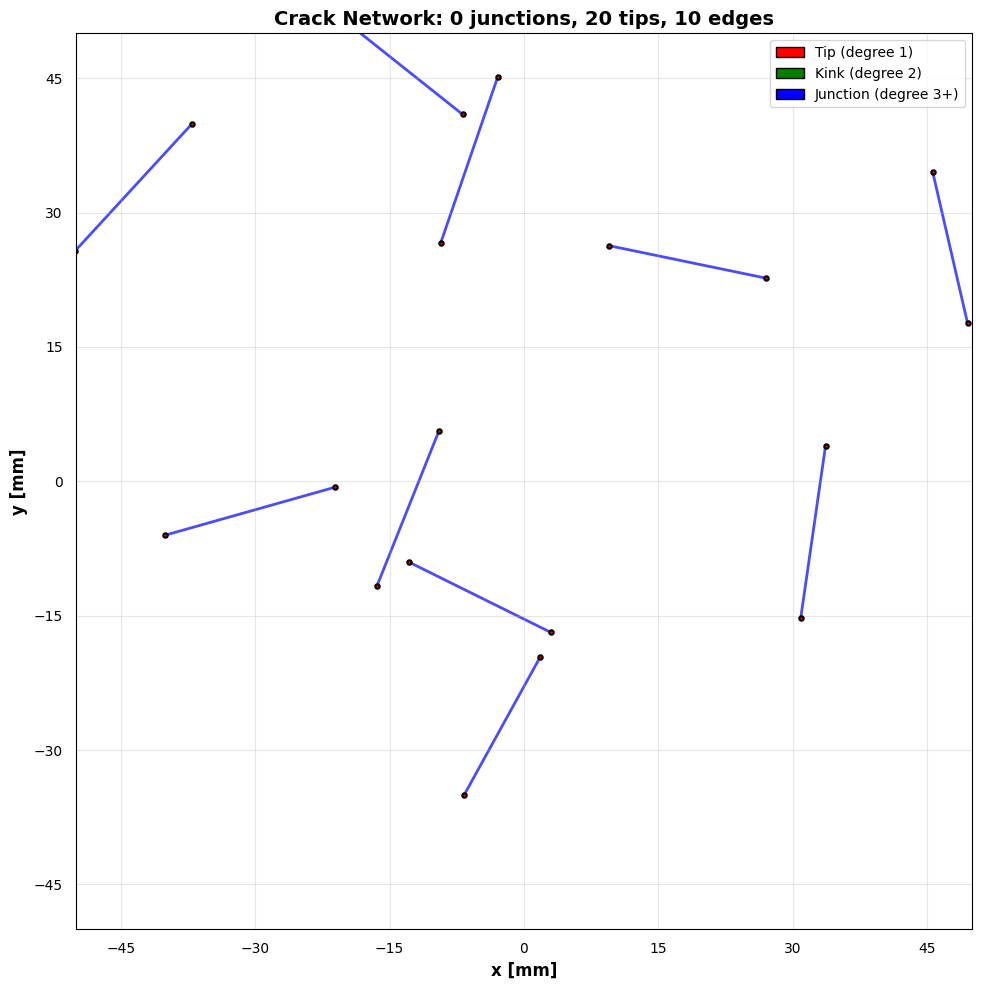


Exported arrays:
  Vertices shape: (20, 3)
  Connectivity shape: (10, 3)
  Vertex types shape: (20,)
  Vertex types: {np.str_('tip')}


In [19]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator as gen, NetworkAnalyzer, NetworkVisualizer


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

# Create generator
mm = 1e-3
generator = gen(
    domain_size=(100*mm, 100*mm),
    seed=42  # For reproducibility
)

# Generate network
generator.generate_network(
    n_junctions=0,           # Number of junction vertices
    n_tips=20,                # Number of tip vertices
    edge_length_mean=40*mm,   # Mean edge length
    edge_length_std=5*mm,    # Std dev of edge length
    max_junction_order=3,    # Max junction degree (3-4 typical)
    spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
    connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
    min_edge_length=5*mm,
    max_edge_length=20*mm
)

# Print statistics
generator.print_statistics()

# Visualize
fig, ax = generator.visualize(
    figsize=(12, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=10,
    edge_color='blue',
    edge_width=2.0
)
plt.show()

# Export to your format
   
    # Export arrays for further analysis
vertices, connectivity, vertex_types = generator.to_arrays()
print(f"\nExported arrays:")
print(f"  Vertices shape: {vertices.shape}")
print(f"  Connectivity shape: {connectivity.shape}")
print(f"  Vertex types shape: {vertex_types.shape}")
print(f"  Vertex types: {set(vertex_types)}")

CRACK NETWORK STATISTICS

Vertices:
  Total: 110
  Tips (degree 1): 100
  Kinks (degree 2): 0
  Junctions (degree 3+): 10

Edges:
  Total: 65
  Length range: [1.03, 2.98] mm
  Mean length: 2.22 mm
  Std dev: 0.54 mm

Degree distribution:
  Degree 1: 100 vertices
  Degree 3: 10 vertices

Connected components (paths): 45


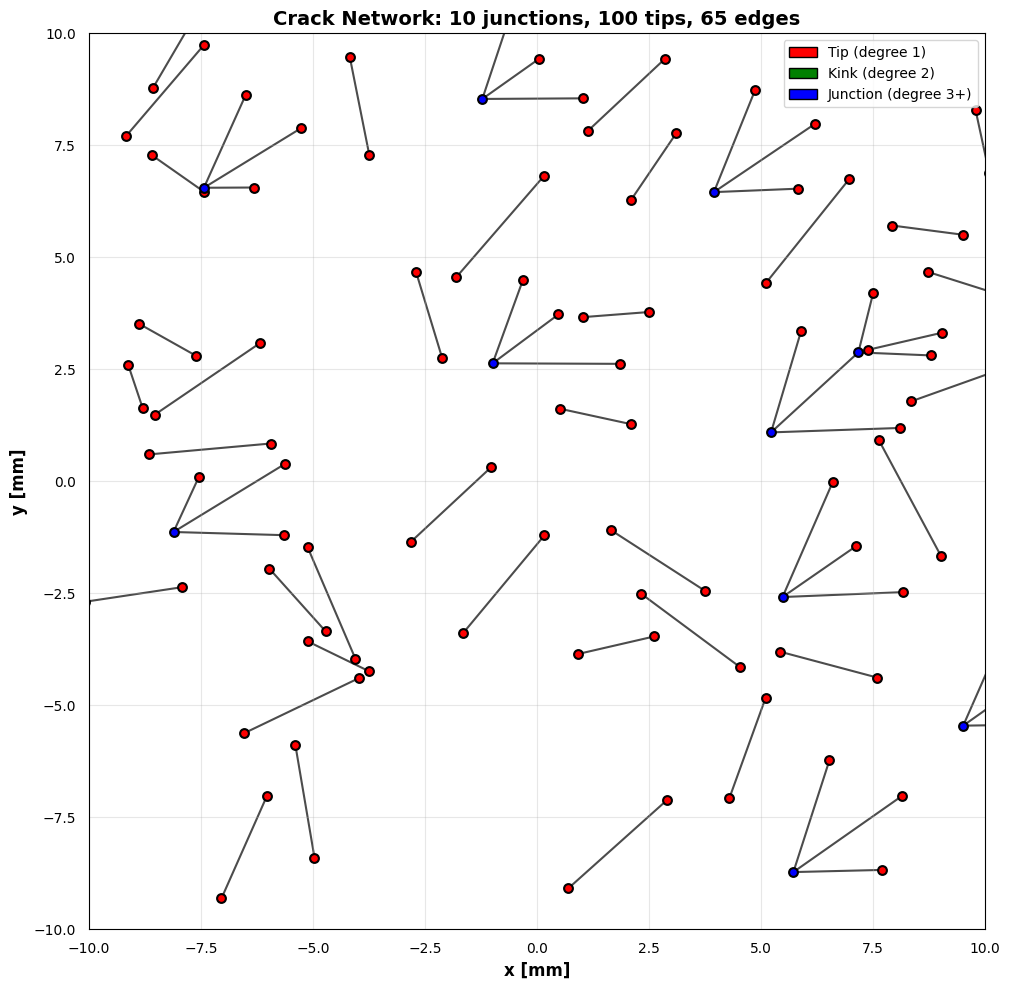


Exported arrays:
  Vertices shape: (110, 3)
  Connectivity shape: (65, 3)
  Vertex types shape: (110,)
  Vertex types: {np.str_('tip'), np.str_('junction')}


In [11]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer

# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    # Create generator
    mm = 1e-3
    generator = CrackNetworkGenerator(
        domain_size=(20*mm, 20*mm),
        seed=42  # For reproducibility
    )
    
    # Generate network WITHOUT intersections
    generator.generate_network(
        n_junctions=10,           # Number of junction vertices
        n_tips=100,               # Number of tip vertices
        edge_length_mean=5*mm,   # Mean edge length
        edge_length_std=2*mm,    # Std dev of edge length
        max_junction_order=3,    # Max junction degree (3-4 typical)
        spatial_distribution='uniform',  # 'uniform', 'clustered', 'grid'
        connection_strategy='nearest_neighbor',  # 'nearest_neighbor', 'delaunay', 'random'
        min_edge_length=1*mm,
        max_edge_length=3*mm,
        allow_intersections=False  # ← Prevent edge crossings
    )
    
    # Print statistics
    generator.print_statistics()
    
    # Visualize
    fig, ax = generator.visualize(
        figsize=(12, 10),
        show_labels=False,
        show_edge_labels=False,
        node_size=40,
        edge_width=1.5,
        edge_color='black'
    )
    plt.show()
    
    # Export arrays for further analysis
vertices, connectivity, vertex_types = generator.to_arrays()
print(f"\nExported arrays:")
print(f"  Vertices shape: {vertices.shape}")
print(f"  Connectivity shape: {connectivity.shape}")
print(f"  Vertex types shape: {vertex_types.shape}")
print(f"  Vertex types: {set(vertex_types)}")

Detecting edge intersections...
Found 3 intersection(s)
  Created junction node 53 at (-2.05, 5.86) mm
    Split edge (1, 2) into 1-53 and 53-2
    Split edge (45, 46) into 45-53 and 53-46
  Created junction node 54 at (-5.87, 0.49) mm
    Split edge (4, 5) into 4-54 and 54-5
    Split edge (40, 41) into 40-54 and 54-41
  Created junction node 55 at (0.28, -5.62) mm
    Split edge (12, 13) into 12-55 and 55-13
    Split edge (23, 24) into 23-55 and 55-24
Successfully processed 3 intersection(s)


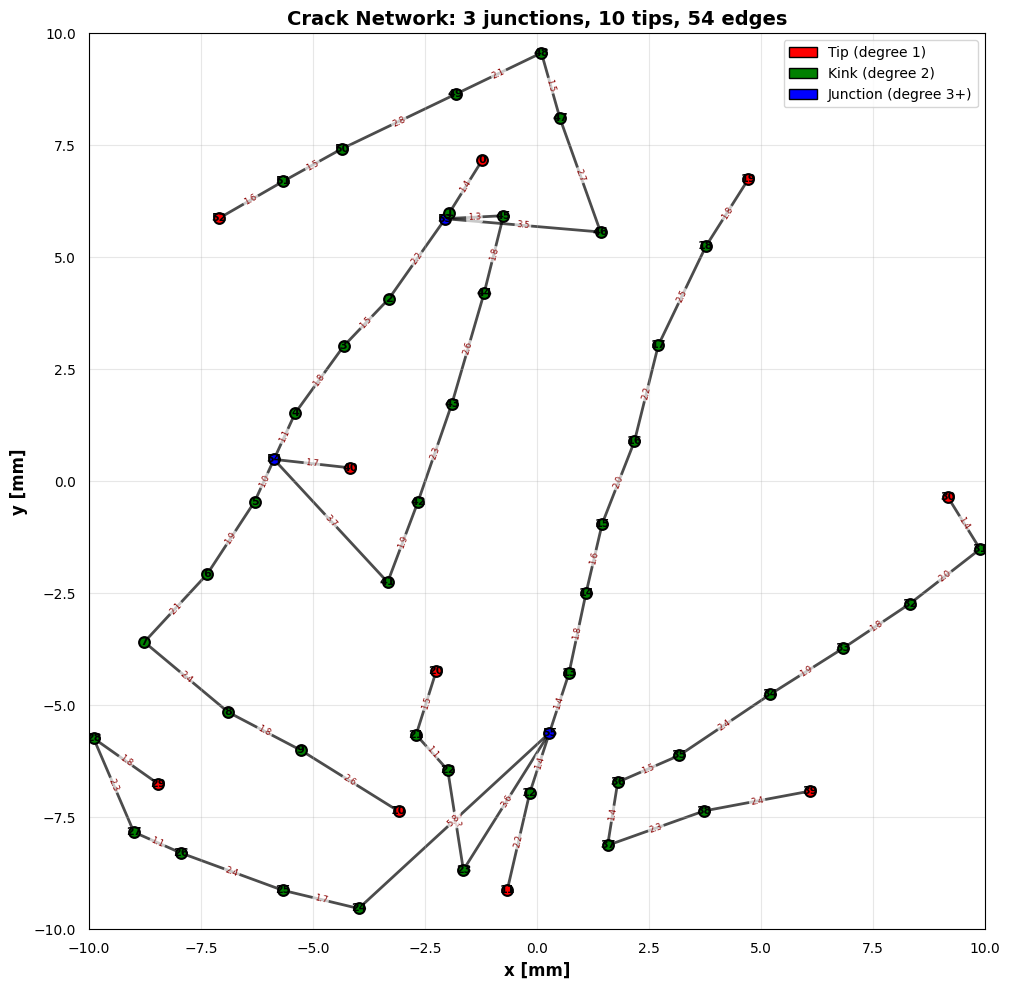

In [9]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer
mm = 1e-3

generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=42
)

generator.generate_network(
    n_junctions=0,              # No junctions
    n_tips=0,                   # No isolated tips
    edge_length_mean=2*mm,
    edge_length_std=0.5*mm,
    min_edge_length=1*mm,
    max_edge_length=3*mm,
    
    # Connected crack paths
    n_crack_paths=5,                    # 5 long cracks
    segments_per_path_mean=10,          # Average 10 segments each
    segments_per_path_std=3,            # ±3 segments variation
    path_angle_change_mean_deg=0.0,     # Straight (no systematic curvature)
    path_angle_change_std_deg=10.0,     # Small random wiggles (±10°)
    
    allow_intersections=True,
    detect_intersections=True,
    min_edge_distance=1.0*mm
)

fig, ax = generator.visualize(node_size=60, edge_width=2.0)
plt.show()

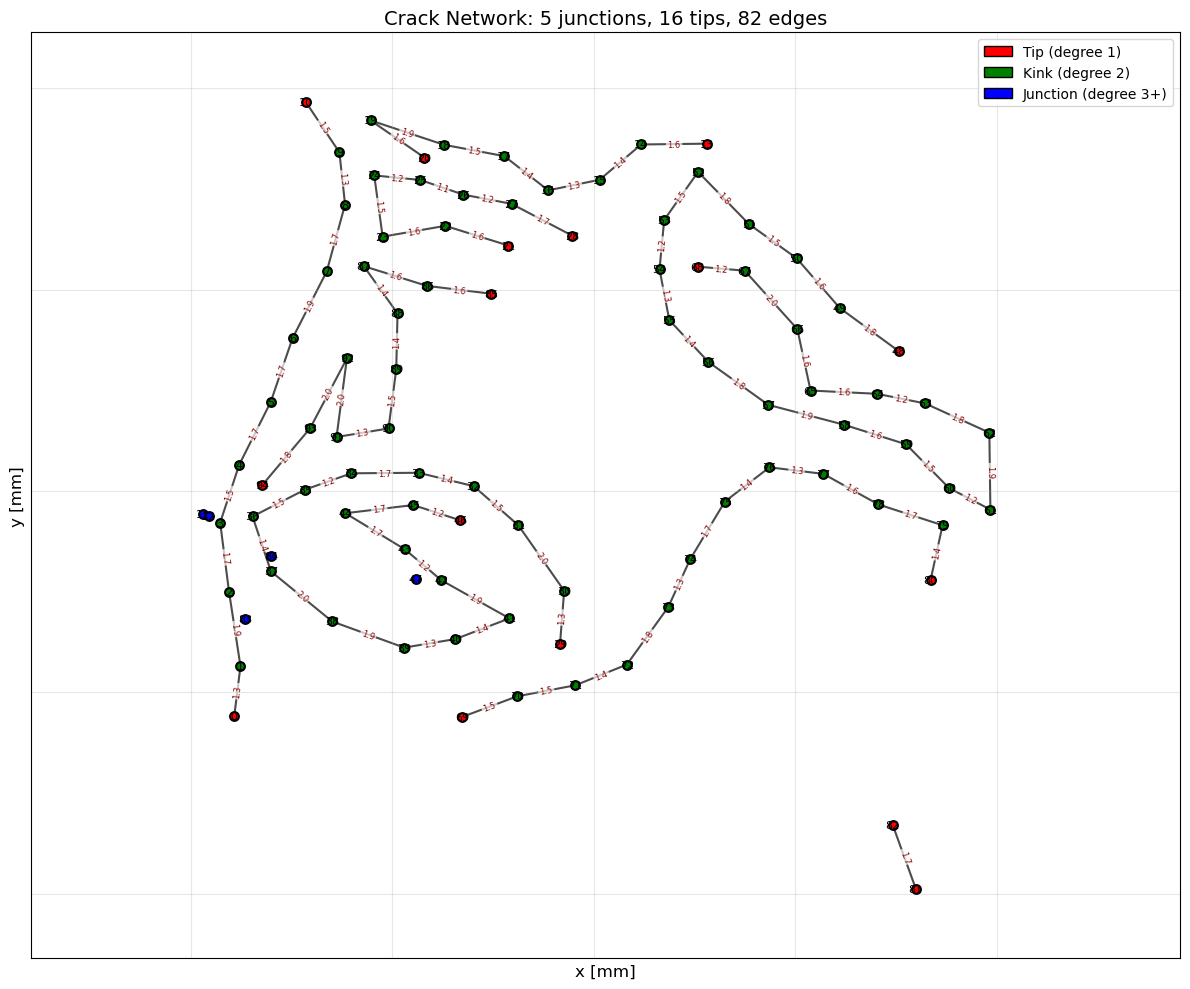

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# Ensure project root is on path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import graph_utils.crack_network_generator  as gen
importlib.reload(gen)
from graph_utils.crack_network_generator import *

generator = CrackNetworkGenerator(
    domain_size=(20*mm, 20*mm),
    seed=123
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    edge_length_mean=1.5*mm,
    edge_length_std=0.3*mm,
    min_edge_length=1*mm,
    max_edge_length=2*mm,
    
    # Curved paths
    n_crack_paths=8,
    segments_per_path_mean=15,          # Longer paths
    segments_per_path_std=5,
    path_angle_change_mean_deg=5.0,     # Slight systematic curve
    path_angle_change_std_deg=20.0,     # Moderate wiggle
    
    allow_intersections=False,
    min_edge_distance=0.5*mm
)

fig, ax = generator.visualize(node_size=40, edge_width=1.5)
plt.show()

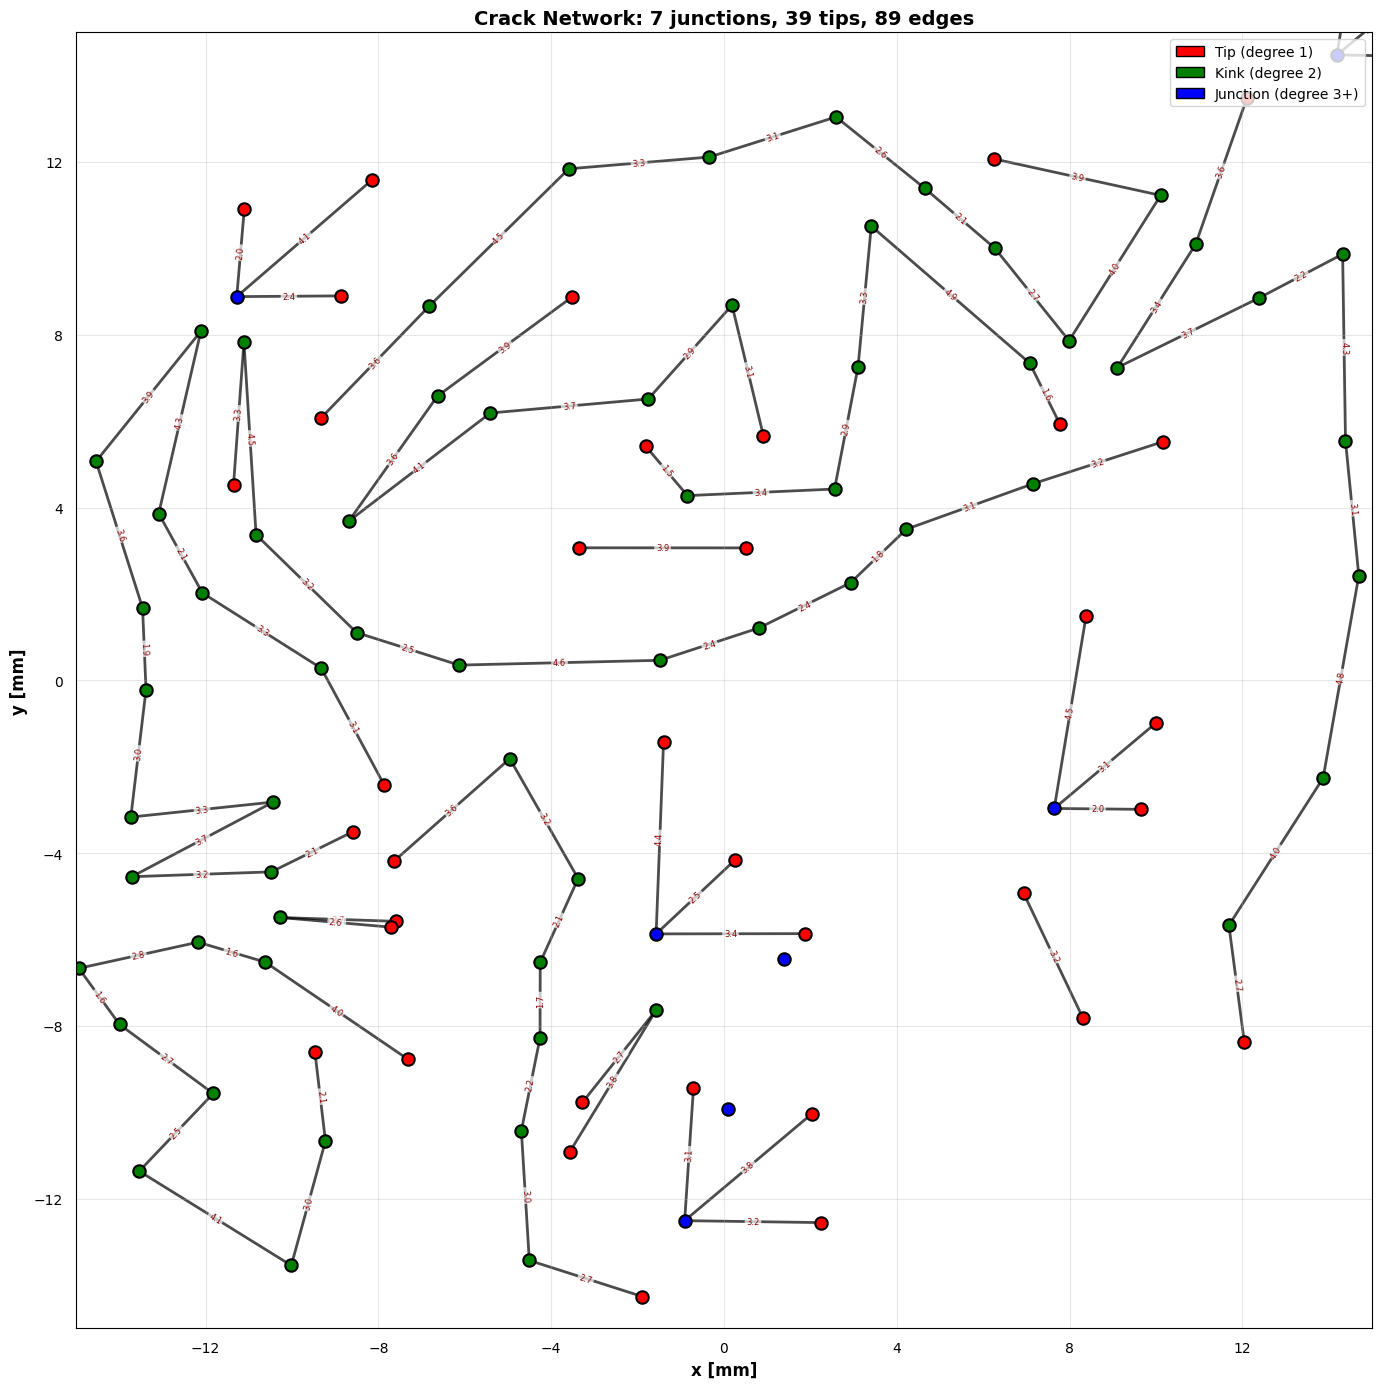

In [8]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer

generator = CrackNetworkGenerator(
    domain_size=(30*mm, 30*mm),
    seed=456
)

generator.generate_network(
    # Junction network
    n_junctions=5,
    n_tips=20,
    max_junction_order=4,
    
    # Edge properties
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    min_edge_length=1.5*mm,
    max_edge_length=5*mm,
    
    # Add long connected cracks
    n_crack_paths=10,                   # 10 polyline cracks
    segments_per_path_mean=8,           # 8 segments each on average
    segments_per_path_std=3,
    path_angle_change_mean_deg=0.0,     # No systematic curvature
    path_angle_change_std_deg=25.0,     # Random direction changes
    
    # Constraints
    allow_intersections=False,
    min_junction_angle_deg=40.0,
    min_edge_distance=1.0*mm,
    
    spatial_distribution='uniform',
    connection_strategy='nearest_neighbor'
)

fig, ax = generator.visualize(
    figsize=(14, 14),
    node_size=80,
    edge_width=2.0,
    show_labels=False
)
plt.show()

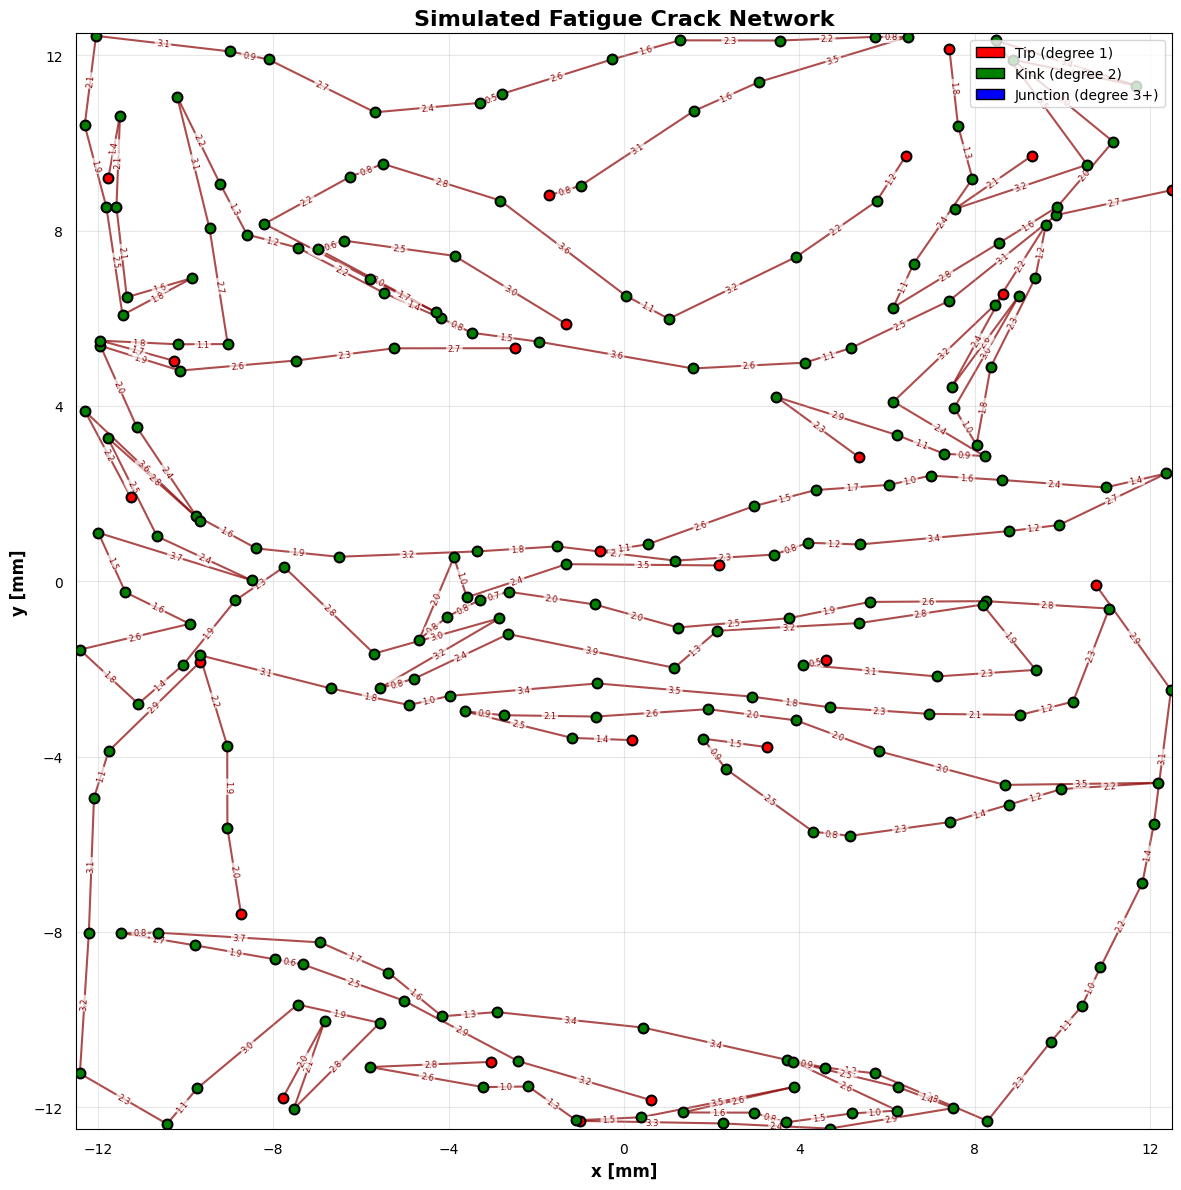

In [ ]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from fracture_utils.Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer
# Simulate fatigue cracks with gradual growth
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=789
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    # Variable segment lengths (crack slows down)
    edge_length_mean=2*mm,
    edge_length_std=1*mm,
    min_edge_length=0.5*mm,
    max_edge_length=4*mm,
    
    # Long propagating cracks
    n_crack_paths=12,
    segments_per_path_mean=20,          # Very long cracks
    segments_per_path_std=8,
    path_angle_change_mean_deg=2.0,     # Slight systematic turn
    path_angle_change_std_deg=15.0,     # Moderate randomness
    
    allow_intersections=False,           # Allow crack coalescence
    min_edge_distance=0.0,              # Allow proximity
    
    spatial_distribution='clustered'    # Clustered nucleation
)

fig, ax = generator.visualize(
    figsize=(12, 12),
    node_size=50,
    edge_width=1.5,
    show_labels=False,
    edge_color='darkred'
)
ax.set_title('Simulated Fatigue Crack Network', fontsize=16, weight='bold')
plt.show()

GENERATING COMPLEX FATIGUE CRACK NETWORK
CRACK NETWORK STATISTICS

Vertices:
  Total: 215
  Tips (degree 1): 24
  Kinks (degree 2): 191
  Junctions (degree 3+): 0

Edges:
  Total: 203
  Length range: [0.34, 3.86] mm
  Mean length: 1.94 mm
  Std dev: 0.88 mm

Degree distribution:
  Degree 1: 24 vertices
  Degree 2: 191 vertices

Connected components (paths): 12

EXPORTING NETWORK DATA

✓ Exported network:
  Vertices shape: (215, 3)
  Connectivity shape: (203, 3)
  Vertices: 215
  Edges: 203

CONFIGURING SIMPLIFICATION

Simplification settings:
  Max angle deviation: 10.0°
  Min edge length: 0.30 mm
  Merge at degree-2 nodes: True
  Remove degree-2 nodes: False

SIMPLIFYING NETWORK
✓ Loaded network: 215 vertices, 203 edges

Before simplification:
  Vertices: 215
  Edges: 203
  Tips: 24
  Junctions: 0
  Internal nodes: 191

SIMPLIFYING CRACK NETWORK
Initial: 215 vertices, 203 edges

Step 1: Merging nearby vertices...
  ✓ Merged 0 vertices

Step 2: Removing small edges...
  ✓ Removed 0 sma

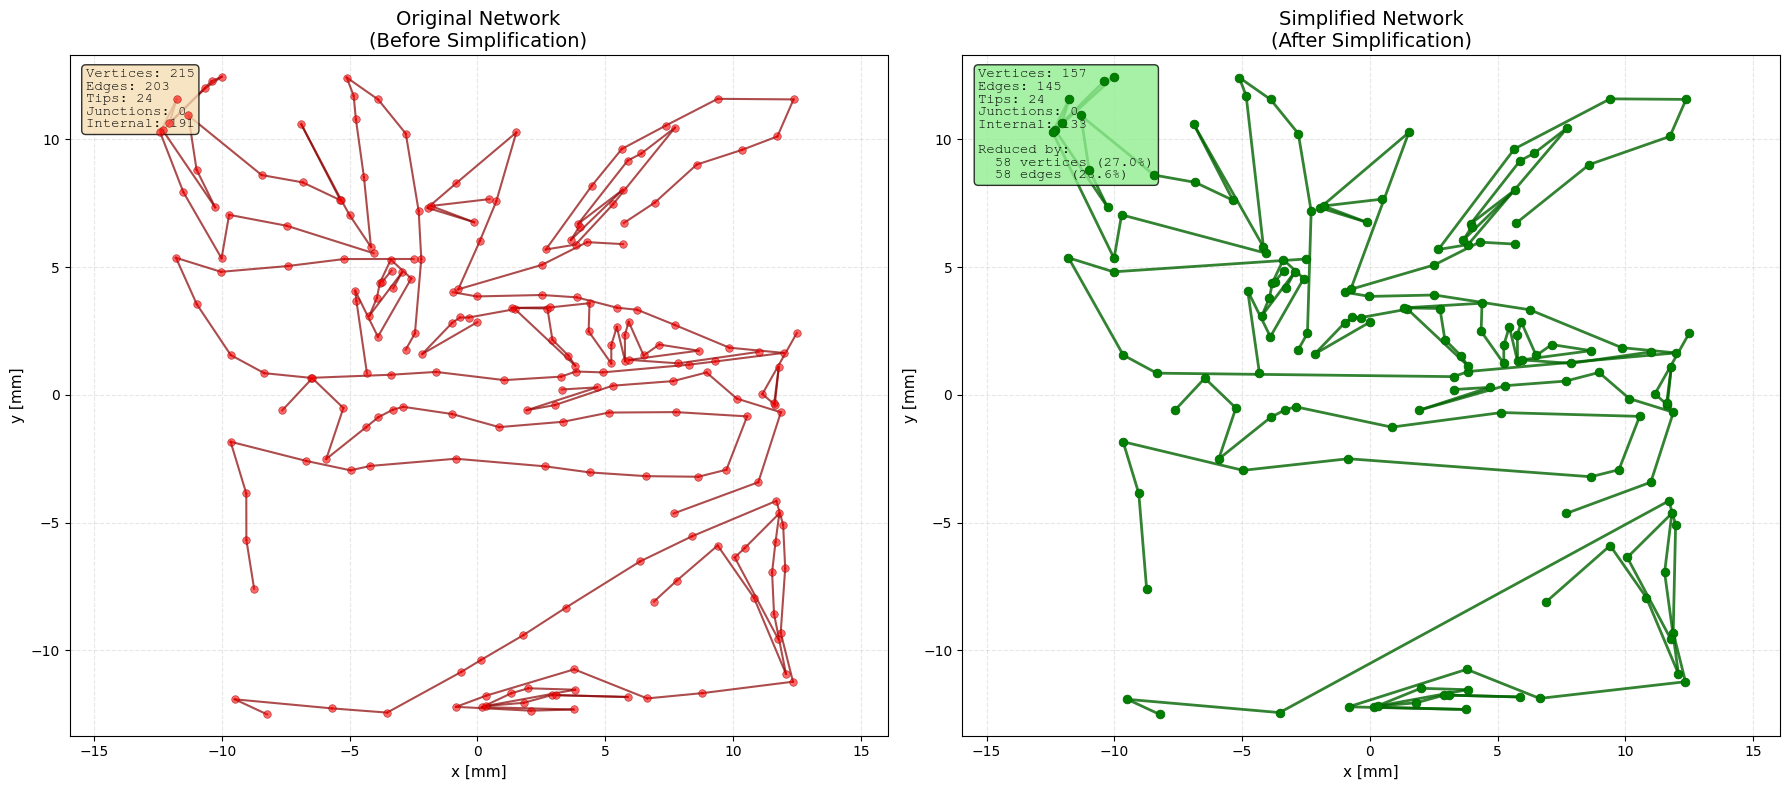


DETAILED STATISTICS

Simplification Summary:
  Vertices merged: 0
  Edges removed (too small): 0
  Edge pairs merged (colinear): 58
  Degree-2 nodes removed: 0

Edge Length Statistics:

Original network:
  Mean edge length: 1.944 mm
  Min edge length: 0.344 mm
  Max edge length: 3.860 mm
  Total crack length: 394.61 mm

Simplified network:
  Mean edge length: 2.719 mm
  Min edge length: 0.344 mm
  Max edge length: 17.336 mm
  Total crack length: 394.32 mm

SIMPLIFICATION COMPLETE!


In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
nb_dir = Path(os.getcwd()).resolve()
repo_root = nb_dir.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    
# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Import from Ugenerator
from fracture_utils.Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer

# Import simplifier
from fracture_utils.Ugenerator.crack_network_simplifier import CrackNetworkSimplifier, SimplificationConfig
out_dir = Path(repo_root) / "output" / "NetworkSimplification"
out_dir.mkdir(parents=True, exist_ok=True)

mm = 1e-3

# ============================================================================
# STEP 1: Generate Complex Network
# ============================================================================

print("="*70)
print("GENERATING COMPLEX FATIGUE CRACK NETWORK")
print("="*70)

generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=789
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    # Variable segment lengths (crack slows down)
    edge_length_mean=2*mm,
    edge_length_std=1*mm,
    min_edge_length=0.1*mm,
    max_edge_length=4*mm,
    
    # Long propagating cracks
    n_crack_paths=12,
    segments_per_path_mean=20,          # Very long cracks
    segments_per_path_std=8,
    path_angle_change_mean_deg=2.0,     # Slight systematic turn
    path_angle_change_std_deg=15.0,     # Moderate randomness
    
    allow_intersections=False,          # Prevent coalescence for now
    min_edge_distance=0.0,              # Allow proximity
    
    spatial_distribution='clustered'    # Clustered nucleation
)

# Show statistics
generator.print_statistics()

# ============================================================================
# STEP 2: Export Original Network
# ============================================================================

print("\n" + "="*70)
print("EXPORTING NETWORK DATA")
print("="*70)

# Export to arrays - get all 3 values
original_vertices, original_connectivity, vertex_types = generator.to_arrays()

print(f"\n✓ Exported network:")
print(f"  Vertices shape: {original_vertices.shape}")
print(f"  Connectivity shape: {original_connectivity.shape}")
print(f"  Vertices: {len(original_vertices)}")
print(f"  Edges: {len(original_connectivity)}")

# ============================================================================
# STEP 3: Configure Simplification
# ============================================================================

print("\n" + "="*70)
print("CONFIGURING SIMPLIFICATION")
print("="*70)

# Create configuration
config = SimplificationConfig(
    max_angle_deviation=10.0,      # Merge edges if angle deviation < 10°
    min_edge_length=0.3*mm,       # Remove edges shorter than 0.3mm
    merge_at_degree2=True,        # Merge colinear edges at internal nodes
    remove_degree2_nodes=False,    # Remove degree-2 internal nodes
    preserve_tips=True,           # Don't remove crack tips
    preserve_junctions=True,      # Don't modify junctions
    max_merged_edge_length=20*mm, # Don't merge if result > 20mm
    merge_vertex_tolerance=1e-6   # Merge vertices closer than this
)

print(f"\nSimplification settings:")
print(f"  Max angle deviation: {config.max_angle_deviation}°")
print(f"  Min edge length: {config.min_edge_length/mm:.2f} mm")
print(f"  Merge at degree-2 nodes: {config.merge_at_degree2}")
print(f"  Remove degree-2 nodes: {config.remove_degree2_nodes}")

# ============================================================================
# STEP 4: Simplify Network
# ============================================================================

print("\n" + "="*70)
print("SIMPLIFYING NETWORK")
print("="*70)

# Create simplifier
simplifier = CrackNetworkSimplifier(config=config)

# Load original network
# Note: original_connectivity might have shape (n, 3) with [edge_id, v0, v1]
# If so, we need to extract just [v0, v1]
if original_connectivity.shape[1] == 3:
    # Has edge_id column - extract just v0, v1
    connectivity_for_simplifier = original_connectivity[:, 1:3]
else:
    # Already in [v0, v1] format
    connectivity_for_simplifier = original_connectivity

simplifier.load_from_arrays(
    original_vertices, 
    connectivity_for_simplifier,
    domain_size=(25*mm, 25*mm)
)

# Get statistics before simplification
stats_before = simplifier.get_statistics()
print(f"\nBefore simplification:")
print(f"  Vertices: {stats_before['n_vertices']}")
print(f"  Edges: {stats_before['n_edges']}")
print(f"  Tips: {stats_before['n_tips']}")
print(f"  Junctions: {stats_before['n_junctions']}")
print(f"  Internal nodes: {stats_before['n_internal']}")

# Simplify!
simplification_stats = simplifier.simplify(verbose=True)

# Get statistics after simplification
stats_after = simplifier.get_statistics()

# Export simplified network
simplified_vertices, simplified_connectivity = simplifier.to_arrays()

print(f"\n✓ Simplification complete!")
print(f"  Original: {len(original_vertices)} vertices, {len(connectivity_for_simplifier)} edges")
print(f"  Simplified: {len(simplified_vertices)} vertices, {len(simplified_connectivity)} edges")
print(f"  Reduction: {len(original_vertices) - len(simplified_vertices)} vertices "
      f"({100*(len(original_vertices) - len(simplified_vertices))/len(original_vertices):.1f}%), "
      f"{len(connectivity_for_simplifier) - len(simplified_connectivity)} edges "
      f"({100*(len(connectivity_for_simplifier) - len(simplified_connectivity))/len(connectivity_for_simplifier):.1f}%)")

# ============================================================================
# STEP 5: Visualize Comparison
# ============================================================================

print("\n" + "="*70)
print("CREATING VISUALIZATION")
print("="*70)

fig = plt.figure(figsize=(18, 8))

# Left: Original network
ax1 = plt.subplot(1, 2, 1)
ax1.set_title('Original Network\n(Before Simplification)', 
              fontsize=14, fontweight='bold')

# Plot edges - handle both formats
for row in connectivity_for_simplifier:
    v0, v1 = int(row[0]), int(row[1])
    pos0 = original_vertices[v0, 1:]
    pos1 = original_vertices[v1, 1:]
    ax1.plot([pos0[0]/mm, pos1[0]/mm], 
            [pos0[1]/mm, pos1[1]/mm], 
            'darkred', linewidth=1.5, alpha=0.7)

# Plot vertices
ax1.scatter(original_vertices[:, 1]/mm, original_vertices[:, 2]/mm, 
           c='red', s=30, zorder=5, alpha=0.6, edgecolors='darkred', linewidths=0.5)

ax1.set_xlabel('x [mm]', fontsize=11)
ax1.set_ylabel('y [mm]', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axis('equal')

# Add info box
info_text = (f'Vertices: {len(original_vertices)}\n'
             f'Edges: {len(connectivity_for_simplifier)}\n'
             f'Tips: {stats_before["n_tips"]}\n'
             f'Junctions: {stats_before["n_junctions"]}\n'
             f'Internal: {stats_before["n_internal"]}')
ax1.text(0.02, 0.98, info_text,
        transform=ax1.transAxes, verticalalignment='top',
        fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Right: Simplified network
ax2 = plt.subplot(1, 2, 2)
ax2.set_title('Simplified Network\n(After Simplification)', 
              fontsize=14, fontweight='bold')

# Plot edges
for v0, v1 in simplified_connectivity:
    idx_v0 = int(v0)
    idx_v1 = int(v1)
    pos0 = simplified_vertices[idx_v0, 1:]
    pos1 = simplified_vertices[idx_v1, 1:]
    ax2.plot([pos0[0]/mm, pos1[0]/mm], 
            [pos0[1]/mm, pos1[1]/mm], 
            'darkgreen', linewidth=2, alpha=0.8)

# Plot vertices
ax2.scatter(simplified_vertices[:, 1]/mm, simplified_vertices[:, 2]/mm, 
           c='green', s=40, zorder=5, edgecolors='darkgreen', linewidths=0.5)

ax2.set_xlabel('x [mm]', fontsize=11)
ax2.set_ylabel('y [mm]', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.axis('equal')

# Add info box
reduction_v = len(original_vertices) - len(simplified_vertices)
reduction_e = len(connectivity_for_simplifier) - len(simplified_connectivity)
info_text = (f'Vertices: {len(simplified_vertices)}\n'
             f'Edges: {len(simplified_connectivity)}\n'
             f'Tips: {stats_after["n_tips"]}\n'
             f'Junctions: {stats_after["n_junctions"]}\n'
             f'Internal: {stats_after["n_internal"]}\n\n'
             f'Reduced by:\n'
             f'  {reduction_v} vertices ({100*reduction_v/len(original_vertices):.1f}%)\n'
             f'  {reduction_e} edges ({100*reduction_e/len(connectivity_for_simplifier):.1f}%)')
ax2.text(0.02, 0.98, info_text,
        transform=ax2.transAxes, verticalalignment='top',
        fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.savefig(out_dir / 'network_simplification_fatigue_cracks.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved comparison plot: {out_dir / 'network_simplification_fatigue_cracks.png'}")
plt.show()

# ============================================================================
# STEP 6: Detailed Comparison Stats
# ============================================================================

print("\n" + "="*70)
print("DETAILED STATISTICS")
print("="*70)

print("\nSimplification Summary:")
print(f"  Vertices merged: {simplification_stats['vertices_merged']}")
print(f"  Edges removed (too small): {simplification_stats['edges_removed']}")
print(f"  Edge pairs merged (colinear): {simplification_stats['edges_merged']}")
print(f"  Degree-2 nodes removed: {simplification_stats['degree2_removed']}")

print("\nEdge Length Statistics:")

# Calculate edge lengths for both networks
def edge_lengths(vertices, connectivity):
    lengths = []
    for row in connectivity:
        v0, v1 = int(row[0]), int(row[1])
        pos0 = vertices[v0, 1:]
        pos1 = vertices[v1, 1:]
        length = np.linalg.norm(pos1 - pos0)
        lengths.append(length)
    return np.array(lengths)

original_lengths = edge_lengths(original_vertices, connectivity_for_simplifier)
simplified_lengths = edge_lengths(simplified_vertices, simplified_connectivity)

print(f"\nOriginal network:")
print(f"  Mean edge length: {np.mean(original_lengths)/mm:.3f} mm")
print(f"  Min edge length: {np.min(original_lengths)/mm:.3f} mm")
print(f"  Max edge length: {np.max(original_lengths)/mm:.3f} mm")
print(f"  Total crack length: {np.sum(original_lengths)/mm:.2f} mm")

print(f"\nSimplified network:")
print(f"  Mean edge length: {np.mean(simplified_lengths)/mm:.3f} mm")
print(f"  Min edge length: {np.min(simplified_lengths)/mm:.3f} mm")
print(f"  Max edge length: {np.max(simplified_lengths)/mm:.3f} mm")
print(f"  Total crack length: {np.sum(simplified_lengths)/mm:.2f} mm")

print("\n" + "="*70)
print("SIMPLIFICATION COMPLETE!")
print("="*70)

CRACK NETWORK STATISTICS

Vertices:
  Total: 10
  Tips (degree 1): 6
  Kinks (degree 2): 4
  Junctions (degree 3+): 0

Edges:
  Total: 7
  Length range: [2.57, 4.08] mm
  Mean length: 3.31 mm
  Std dev: 0.53 mm

Degree distribution:
  Degree 1: 6 vertices
  Degree 2: 4 vertices

Connected components (paths): 3
  Path 1: 3 vertices, 2 edges
  Path 2: 4 vertices, 3 edges
  Path 3: 3 vertices, 2 edges


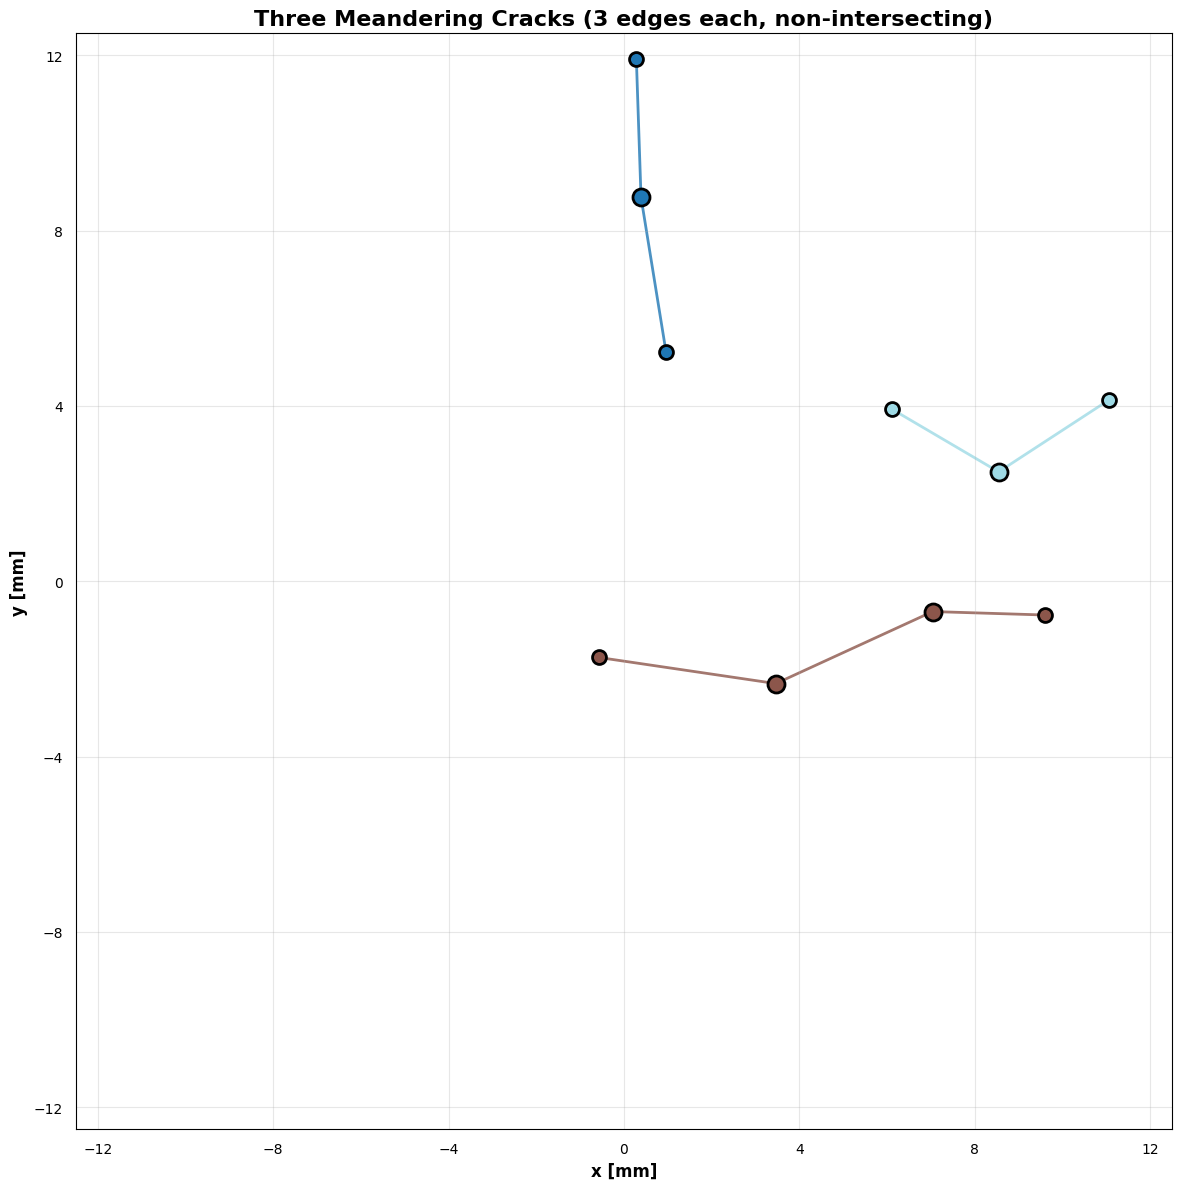

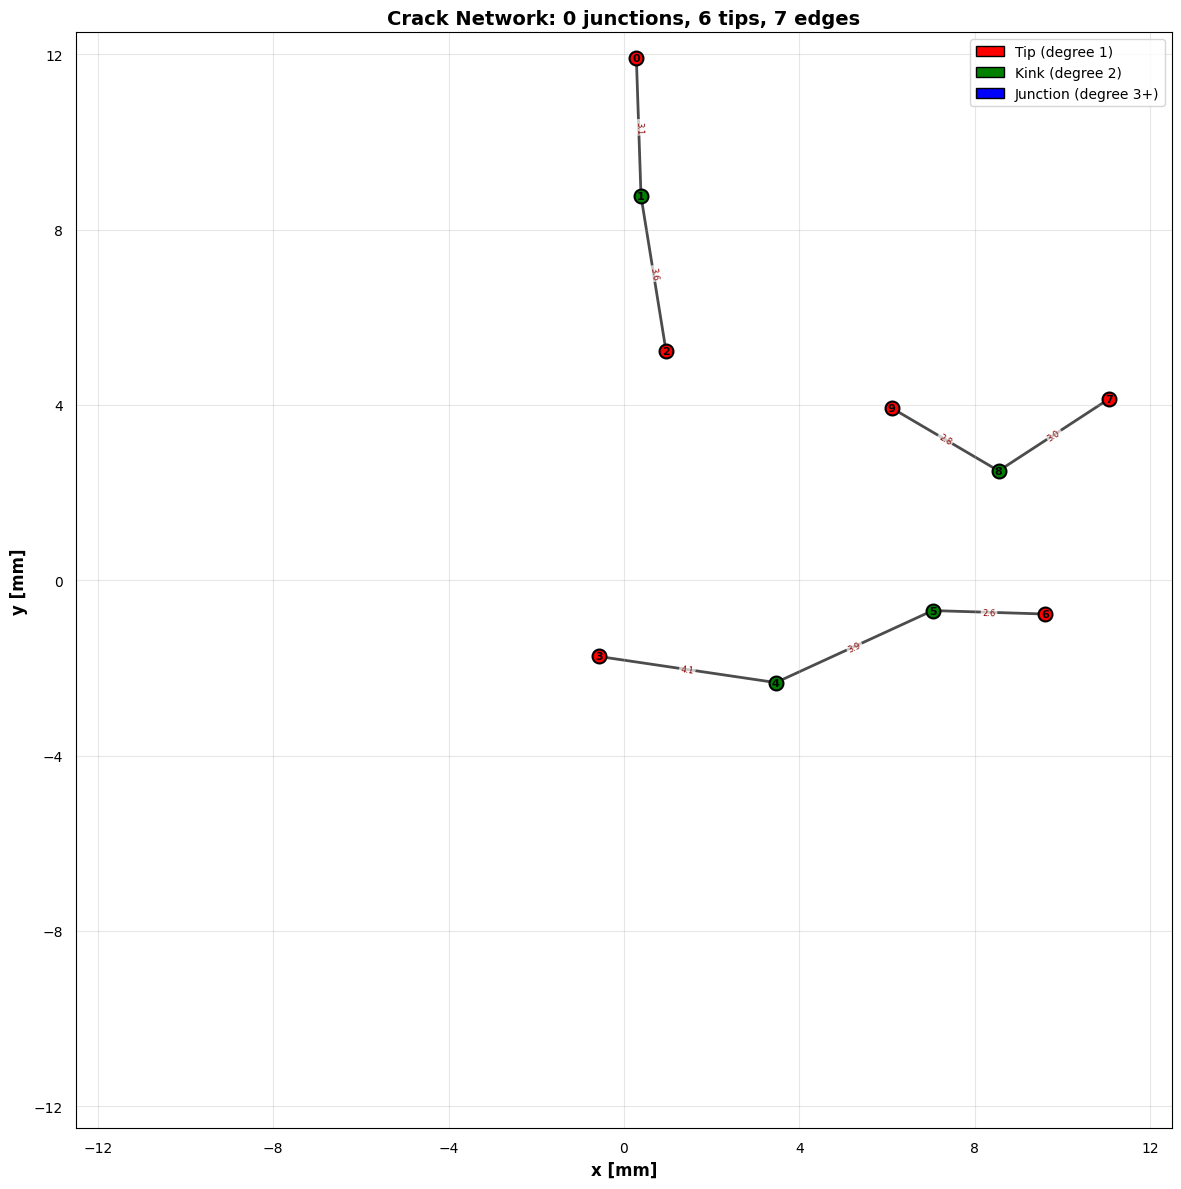


Exported arrays:
  Vertices shape: (10, 3)
  Connectivity shape: (7, 3)
  Vertex types shape: (10,)
  Vertex types: {np.str_('tip'), np.str_('kink')}


In [4]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer

mm=1e-3
# Generate exactly 3 non-intersecting meandering cracks, each with 3 edges
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=4  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=0,
    n_tips=0,
    
    # Edge properties for meandering
    edge_length_mean=3*mm,
    edge_length_std=0.5*mm,
    min_edge_length=2*mm,
    max_edge_length=6*mm,
    
    # Exactly 3 cracks, each with 3 segments
    n_crack_paths=3,
    segments_per_path_mean=3,
    segments_per_path_std=1,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=30.0,     # Small random angles (±30°)
    
    # Non-intersecting
    allow_intersections=False,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='uniform'
)

# Print statistics
generator.print_statistics()

# Visualize with path coloring to see the 3 separate cracks
fig, ax = generator.visualize_with_paths(figsize=(12, 12))
ax.set_title('Three Meandering Cracks (3 edges each, non-intersecting)', 
             fontsize=16, weight='bold')
plt.show()

# Also show standard visualization
fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=100,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()

# Export arrays for further analysis
vertices, connectivity, vertex_types = generator.to_arrays()
print(f"\nExported arrays:")
print(f"  Vertices shape: {vertices.shape}")
print(f"  Connectivity shape: {connectivity.shape}")
print(f"  Vertex types shape: {vertex_types.shape}")
print(f"  Vertex types: {set(vertex_types)}")

Detecting edge intersections...
Found 0 intersection(s)
CRACK NETWORK STATISTICS

Vertices:
  Total: 21
  Tips (degree 1): 13
  Kinks (degree 2): 4
  Junctions (degree 3+): 4

Edges:
  Total: 16
  Length range: [2.19, 7.06] mm
  Mean length: 4.75 mm
  Std dev: 1.39 mm

Degree distribution:
  Degree 0: 1 vertices
  Degree 1: 13 vertices
  Degree 2: 4 vertices
  Degree 3: 1 vertices
  Degree 4: 2 vertices

Connected components (paths): 5
  Path 1: 7 vertices, 6 edges
  Path 2: 5 vertices, 4 edges
  Path 3: 1 vertices, 0 edges
  Path 4: 3 vertices, 2 edges
  Path 5: 5 vertices, 4 edges


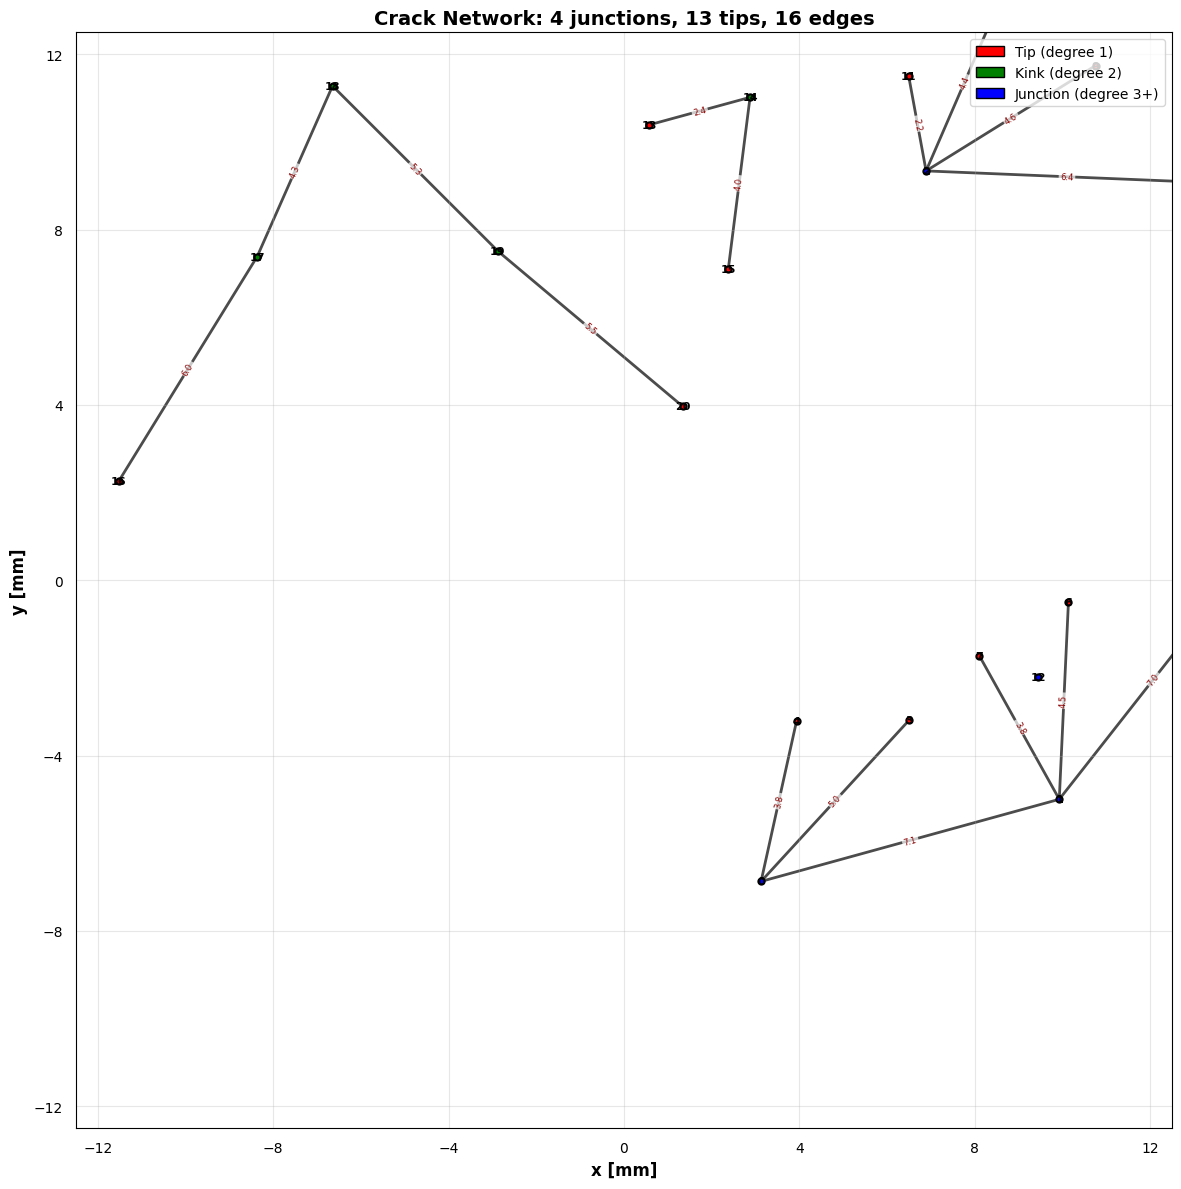

In [1]:

import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer

# ----------------------------
# Problem definition
# ----------------------------
mm = 1e-3
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=7  # Change seed for different patterns
)

generator.generate_network(
    n_junctions=3,
    n_tips=6,
    
    # Edge properties for meandering
    edge_length_mean=5*mm,
    edge_length_std=2*mm,
    min_edge_length=2*mm,
    max_edge_length=10*mm,

    # Exactly 4 cracks, each with 4 segments
    n_crack_paths=2,
    segments_per_path_mean=4,
    segments_per_path_std=2,  # Some variation in segments per path
    
    # Small random angles for meandering
    path_angle_change_mean_deg=0.0,     # No systematic turn
    path_angle_change_std_deg=10.0,     # Small random angles (±10°)

    # Non-intersecting
    allow_intersections=True,
    detect_intersections=True,
    min_edge_distance=1.0*mm,  # Keep cracks separated
    
    spatial_distribution='uniform'
)


# Print statistics
generator.print_statistics()

fig2, ax2 = generator.visualize(
    figsize=(12, 12),
    node_size=20,
    edge_width=2.0,
    show_labels=True,
    show_edge_labels=True,
    edge_color='black'
)
plt.show()
vertices, connectivity, vertex_types = generator.to_arrays()




Detecting edge intersections...
Found 0 intersection(s)
CRACK NETWORK STATISTICS

Vertices:
  Total: 25
  Tips (degree 1): 20
  Kinks (degree 2): 0
  Junctions (degree 3+): 5

Edges:
  Total: 19
  Length range: [1.61, 9.95] mm
  Mean length: 5.08 mm
  Std dev: 1.95 mm

Degree distribution:
  Degree 1: 20 vertices
  Degree 3: 2 vertices
  Degree 4: 3 vertices

Connected components (paths): 6
  Path 1: 10 vertices, 9 edges
  Path 2: 5 vertices, 4 edges
  Path 3: 4 vertices, 3 edges
  Path 4: 2 vertices, 1 edges
  Path 5: 2 vertices, 1 edges
  Path 6: 2 vertices, 1 edges


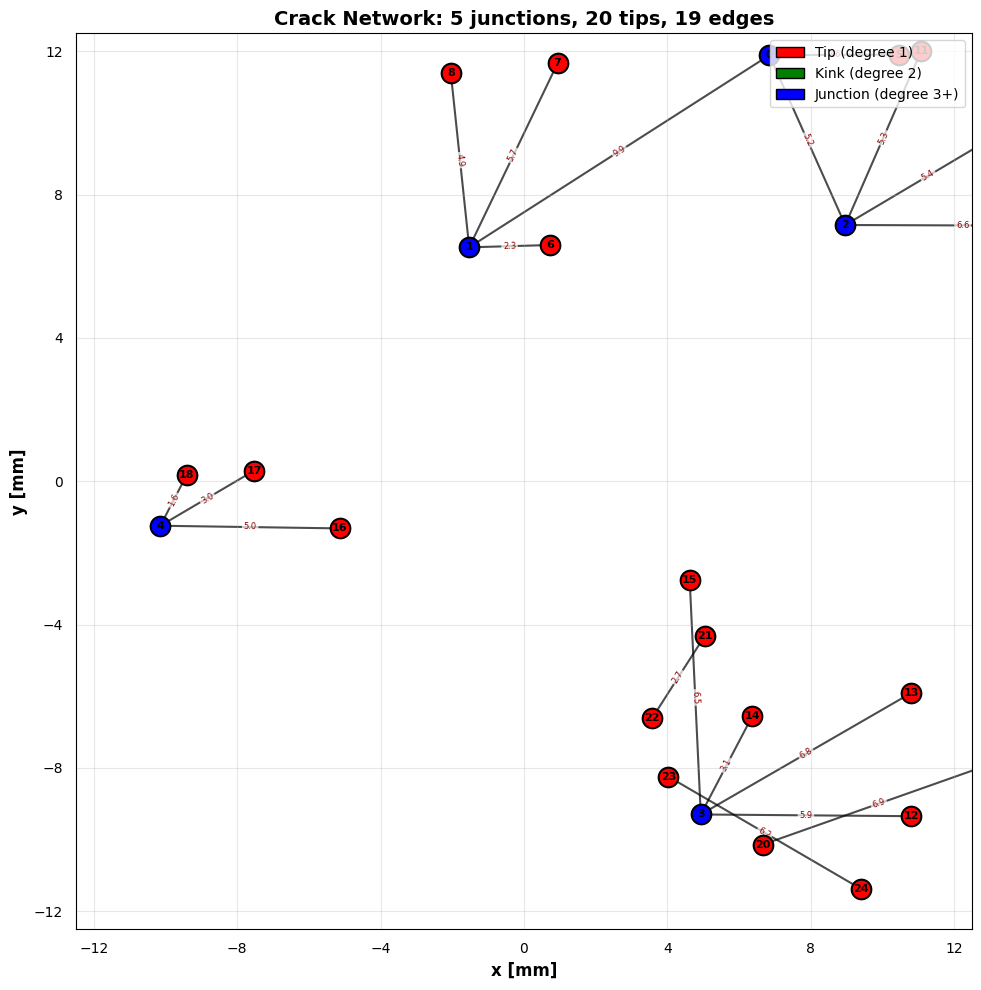

In [2]:
import sys
import os
import matplotlib.pyplot as plt

# Get the path to fracture_utils
notebook_dir = os.getcwd()  # Current notebook directory
fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
sys.path.insert(0, os.path.abspath(fracture_utils_path))

# Now import from Ugenerator
from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer, NetworkVisualizer

mm = 1e-3
generator = CrackNetworkGenerator(domain_size=(25*mm, 25*mm), seed=42)

generator.generate_network(
    n_junctions=5,
    n_tips=20,
    allow_intersections=True,
    detect_intersections=True,
)

# Use modular components
analyzer = NetworkAnalyzer(generator.G)
analyzer.print_statistics()

visualizer = NetworkVisualizer(generator.G, (25*mm, 25*mm))
fig, ax = visualizer.visualize()
plt.show()

In [2]:
"""
Example: Using the Boundary Module

This demonstrates how to:
1. Create boundaries (circle, rectangle, polygon)
2. Generate cracks within boundaries
3. Detect and trim crack-boundary intersections
4. Visualize bounded crack networks
"""
from pathlib import Path
import os, sys

# --- Ensure repo root on sys.path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# --- Preamble re-exports
from preamble import *   
enable_autoreload()


# import sys
# import os
# import matplotlib.pyplot as plt
# import numpy as np

# # Get the path to fracture_utils
# notebook_dir = os.getcwd()  # Current notebook directory
# fracture_utils_path = os.path.join(notebook_dir, '..', 'fracture_utils')
# sys.path.insert(0, os.path.abspath(fracture_utils_path))

# # Now import from Ugenerator
# from Ugenerator import CrackNetworkGenerator, NetworkAnalyzer,                                   NetworkVisualizer, NetworkVisualizer
# from Ugenerator.boundary import (Boundary, BoundaryManager)

out_dir = Path(r"/Users/ghoni/Documents/GitHub/Fracture/VCM_1_3/output/BoundaryExamples")
out_dir.mkdir(parents=True, exist_ok=True)




mm = 1e-3

print("="*60)
print("Boundary Module Examples")
print("="*60)

# =============================================================================
# Example 1: Circular Boundary (Like your BEM disk)
# =============================================================================
print("\n1. Circular Boundary Example")
print("-"*60)

# Create circular boundary
radius = 10*mm
boundary_circle = Boundary.create_circle(center=np.array([0, 0]), radius=radius)

# Generate crack network (some cracks will extend outside)
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),  # Larger than boundary
    seed=42
)

generator.generate_network(
    n_junctions=3,
    n_tips=10,
    n_crack_paths=5,
    segments_per_path_mean=4,
    edge_length_mean=4*mm,
    edge_length_std=1*mm,
    path_angle_change_std_deg=25.0,
    allow_intersections=True,
    detect_intersections=False,
    spatial_distribution='uniform'
)

print(f"Generated {generator.G.number_of_nodes()} nodes, {generator.G.number_of_edges()} edges")

# Trim cracks at boundary
boundary_manager = BoundaryManager(boundary_circle)
generator.G = boundary_manager.trim_cracks_at_boundary(generator.G, verbose=True)

# Add boundary to graph for visualization
generator.G = boundary_manager.add_boundary_to_graph(generator.G, n_points_per_segment=100)

# Visualize
visualizer = NetworkVisualizer(generator.G, (25*mm, 25*mm))

fig, ax = visualizer.visualize(
    figsize=(10, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=60,
    edge_width=1.5
)
ax.set_title('Crack Network in Circular Boundary', fontsize=14, weight='bold')

# Highlight boundary edges in red
pos = {n: generator.G.nodes[n]['pos'] for n in generator.G.nodes()}
pos_mm = {k: (v[0]*1e3, v[1]*1e3) for k, v in pos.items()}

boundary_edges = [(u, v) for u, v, d in generator.G.edges(data=True) 
                  if d.get('type') == 'boundary']
import networkx as nx
nx.draw_networkx_edges(generator.G, pos_mm, edgelist=boundary_edges,
                       edge_color='red', width=2.0, ax=ax)

plt.savefig(str(out_dir) + "/example_circular_boundary.png", dpi=150, bbox_inches="tight")
print("Saved: example_circular_boundary.png")
plt.close()

# =============================================================================
# Example 2: Rectangular Boundary
# =============================================================================
print("\n2. Rectangular Boundary Example")
print("-"*60)

# Create rectangular boundary
boundary_rect = Boundary.create_rectangle(
    xmin=-10*mm, xmax=10*mm,
    ymin=-8*mm, ymax=8*mm
)

# Generate cracks
generator2 = CrackNetworkGenerator(domain_size=(25*mm, 25*mm), seed=123)
generator2.generate_network(
    n_junctions=4,
    n_tips=15,
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    allow_intersections=False,
    spatial_distribution='uniform'
)

# Trim and add boundary
boundary_manager2 = BoundaryManager(boundary_rect)
generator2.G = boundary_manager2.trim_cracks_at_boundary(generator2.G, verbose=True)
generator2.G = boundary_manager2.add_boundary_to_graph(generator2.G)

# Visualize
visualizer2 = NetworkVisualizer(generator2.G, (25*mm, 25*mm))
fig, ax = visualizer2.visualize(
    figsize=(10, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=60
)
ax.set_title('Crack Network in Rectangular Boundary', fontsize=14, weight='bold')
plt.savefig(str(out_dir) + "/example_rectangular_boundary.png", dpi=150, bbox_inches="tight")
print("Saved: example_rectangular_boundary.png")
plt.close()

# =============================================================================
# Example 3: Custom Polygon Boundary
# =============================================================================
print("\n3. Custom Polygon Boundary Example")
print("-"*60)

# Create hexagonal boundary
n_sides = 6
angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
radius = 10*mm
hex_vertices = [radius * np.array([np.cos(a), np.sin(a)]) for a in angles]

boundary_hex = Boundary.create_polygon(hex_vertices)

# Generate cracks with paths
generator3 = CrackNetworkGenerator(domain_size=(25*mm, 25*mm), seed=456)
generator3.generate_network(
    n_junctions=0,
    n_tips=0,
    n_crack_paths=8,
    segments_per_path_mean=6,
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    path_angle_change_std_deg=20.0,
    allow_intersections=True,
    spatial_distribution='uniform'
)

# Trim and add boundary
boundary_manager3 = BoundaryManager(boundary_hex)
generator3.G = boundary_manager3.trim_cracks_at_boundary(generator3.G, verbose=True)
generator3.G = boundary_manager3.add_boundary_to_graph(generator3.G)

# Visualize with paths
visualizer3 = NetworkVisualizer(generator3.G, (25*mm, 25*mm))
fig, ax = visualizer3.visualize_with_paths(figsize=(10, 10))
ax.set_title('Crack Paths in Hexagonal Boundary', fontsize=14, weight='bold')
plt.savefig(str(out_dir) + "/example_hexagon_boundary.png", dpi=150, bbox_inches="tight")
print("Saved: example_hexagon_boundary.png")
plt.close()

# =============================================================================
# Example 4: Preventing Generation Outside Boundary
# =============================================================================
print("\n4. Generate Cracks Only Inside Boundary")
print("-"*60)

# You can also filter positions during generation
# This is more efficient than trimming after

boundary_disk = Boundary.create_circle(center=np.array([0, 0]), radius=12*mm)
boundary_manager4 = BoundaryManager(boundary_disk)

# Generate positions
generator4 = CrackNetworkGenerator(domain_size=(25*mm, 25*mm), seed=789)

# Manually generate positions inside boundary
n_attempts = 100
junction_positions = []
for _ in range(n_attempts):
    pos = generator4._generate_positions(1, 'uniform')[0]
    if boundary_disk.is_point_inside(pos):
        junction_positions.append(pos)
        if len(junction_positions) >= 5:
            break

junction_positions = np.array(junction_positions)
print(f"Generated {len(junction_positions)} junction positions inside boundary")

# Now use these positions... (would need to modify generator to accept positions)
# For now, we can demonstrate the concept:

# Generate network and trim
generator4.generate_network(
    n_junctions=5,
    n_tips=12,
    edge_length_mean=3*mm,
    edge_length_std=1*mm,
    allow_intersections=False,
    spatial_distribution='uniform'
)

generator4.G = boundary_manager4.trim_cracks_at_boundary(generator4.G, verbose=True)
generator4.G = boundary_manager4.add_boundary_to_graph(generator4.G)

visualizer4 = NetworkVisualizer(generator4.G, (25*mm, 25*mm))
fig, ax = visualizer4.visualize(figsize=(10, 10), show_labels=False, node_size=50)
ax.set_title('Cracks Trimmed at Circular Boundary', fontsize=14, weight='bold')
plt.savefig(str(out_dir) + "/example_trimmed_boundary.png", dpi=150, bbox_inches="tight")
print("Saved: example_trimmed_boundary.png")
plt.close()

# =============================================================================
# Example 5: Point Inside/Outside Testing
# =============================================================================
print("\n5. Inside/Outside Testing")
print("-"*60)

boundary_test = Boundary.create_circle(center=np.array([0, 0]), radius=10*mm)

test_points = [
    np.array([0, 0]),
    np.array([5*mm, 0]),
    np.array([15*mm, 0]),
    np.array([7*mm, 7*mm]),
]

for i, point in enumerate(test_points):
    inside = boundary_test.is_point_inside(point)
    status = "INSIDE" if inside else "OUTSIDE"
    print(f"  Point {i+1} at ({point[0]*1e3:.1f}, {point[1]*1e3:.1f}) mm: {status}")

print("\n" + "="*60)
print("Examples complete!")
print("="*60)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Boundary Module Examples

1. Circular Boundary Example
------------------------------------------------------------
Generated 33 nodes, 26 edges
Trimming cracks at boundary...
  Removed 26 edges completely outside
  Trimmed 0 edges at boundary
  Added 0 boundary intersection nodes
  Removed 33 isolated nodes
Saved: example_circular_boundary.png

2. Rectangular Boundary Example
------------------------------------------------------------
Trimming cracks at boundary...
  Removed 10 edges completely outside
  Trimmed 0 edges at boundary
  Added 0 boundary intersection nodes
  Removed 13 isolated nodes
Saved: example_rectangular_boundary.png

3. Custom Polygon Boundary Example
------------------------------------------------------------
Trimming cracks at boundary...
  Removed 24 edges completely outside
  Trimmed 2 edges at boundary
  Added 2 boundary intersection nodes
  Removed 27 isolated nodes
Save

In [ ]:
"""
Example: CAD Import for Boundary Definitions

Demonstrates importing boundaries from various CAD formats:
- DXF files (AutoCAD)
- SVG files (vector graphics)
- Text files (simple formats)
- Numpy arrays (programmatic)
- STL files (2D projection)

Also shows manual creation methods.
"""

import numpy as np
import matplotlib.pyplot as plt
from Ugenerator import (
    CrackNetworkGenerator,
    Boundary,
    BoundaryManager,
    CADImporter,
    CADExporter,
    NetworkVisualizer
)

mm = 1e-3

print("="*70)
print("CAD Import Examples for Boundary Definitions")
print("="*70)

# =============================================================================
# Method 1: Manual Creation (Built-in Shapes)
# =============================================================================
print("\n1. Manual Creation - Built-in Shapes")
print("-"*70)

# Circle (like your BEM disk)
boundary_circle = Boundary.create_circle(
    center=np.array([0, 0]), 
    radius=10*mm
)
print("✓ Created circular boundary (radius = 10 mm)")

# Rectangle
boundary_rect = Boundary.create_rectangle(
    xmin=-10*mm, xmax=10*mm,
    ymin=-8*mm, ymax=8*mm
)
print("✓ Created rectangular boundary (20mm × 16mm)")

# Regular polygon (hexagon)
n_sides = 6
angles = np.linspace(0, 2*np.pi, n_sides, endpoint=False)
radius = 10*mm
vertices = [radius * np.array([np.cos(a), np.sin(a)]) for a in angles]
boundary_hex = Boundary.create_polygon(vertices)
print(f"✓ Created hexagonal boundary ({n_sides} sides)")

# =============================================================================
# Method 2: From Numpy Arrays
# =============================================================================
print("\n2. From Numpy Arrays")
print("-"*70)

# Define vertices manually
vertices = np.array([
    [-10, -10],
    [10, -10],
    [10, 10],
    [-10, 10]
]) * mm

# Option A: Sequential connectivity (assumes closed loop)
boundary_from_vertices = CADImporter.from_numpy_arrays(vertices)
print("✓ Created boundary from vertex array (sequential connectivity)")

# Option B: Explicit connectivity
connectivity = np.array([
    [0, 1],  # Edge 0: vertex 0 to vertex 1
    [1, 2],  # Edge 1: vertex 1 to vertex 2
    [2, 3],  # Edge 2: vertex 2 to vertex 3
    [3, 0]   # Edge 3: vertex 3 to vertex 0
])
boundary_from_arrays = CADImporter.from_numpy_arrays(vertices, connectivity)
print("✓ Created boundary from vertex + connectivity arrays")

# =============================================================================
# Method 3: From Text File
# =============================================================================
print("\n3. From Text File")
print("-"*70)

# Create example text file with vertices
example_vertices = np.array([
    [0, 0],
    [15, 0],
    [15, 10],
    [0, 10]
]) * mm

# Save to file
np.savetxt('boundary_vertices.txt', example_vertices, 
          header='x y', comments='', fmt='%.6e')
print("✓ Created example text file: boundary_vertices.txt")

# Import from text file
boundary_from_text = CADImporter.from_text_file(
    'boundary_vertices.txt', 
    format='vertices'
)
print("✓ Imported boundary from text file")

# =============================================================================
# Method 4: From DXF File (if ezdxf available)
# =============================================================================
print("\n4. From DXF File (AutoCAD format)")
print("-"*70)

try:
    import ezdxf
    
    # Create example DXF file
    doc = ezdxf.new('R2010')
    msp = doc.modelspace()
    
    # Add a rectangle to DXF
    rect_points = [
        (-12*mm*1e3, -12*mm*1e3),  # DXF typically uses mm
        (12*mm*1e3, -12*mm*1e3),
        (12*mm*1e3, 12*mm*1e3),
        (-12*mm*1e3, 12*mm*1e3),
        (-12*mm*1e3, -12*mm*1e3)  # Close
    ]
    msp.add_lwpolyline(rect_points, dxfattribs={'layer': 'BOUNDARY'})
    
    # Add a circle
    msp.add_circle((0, 0), 5*mm*1e3, dxfattribs={'layer': 'BOUNDARY'})
    
    doc.saveas('example_boundary.dxf')
    print("✓ Created example DXF file: example_boundary.dxf")
    
    # Import from DXF
    boundary_from_dxf = CADImporter.from_dxf(
        'example_boundary.dxf',
        layer='BOUNDARY',
        scale=mm  # Convert from mm to meters
    )
    print("✓ Imported boundary from DXF file")
    
except ImportError:
    print("⚠ ezdxf not installed. Install with: pip install ezdxf")
    print("  Skipping DXF import example")

# =============================================================================
# Method 5: From SVG File (if svgpathtools available)
# =============================================================================
print("\n5. From SVG File (vector graphics)")
print("-"*70)

try:
    from svgpathtools import Path, Line, wsvg
    
    # Create simple SVG with a rectangle
    path = Path(
        Line(complex(-10, -10), complex(10, -10)),
        Line(complex(10, -10), complex(10, 10)),
        Line(complex(10, 10), complex(-10, 10)),
        Line(complex(-10, 10), complex(-10, -10))
    )
    
    wsvg([path], filename='example_boundary.svg')
    print("✓ Created example SVG file: example_boundary.svg")
    
    # Import from SVG
    boundary_from_svg = CADImporter.from_svg(
        'example_boundary.svg',
        scale=mm
    )
    print("✓ Imported boundary from SVG file")
    
except ImportError:
    print("⚠ svgpathtools not installed. Install with: pip install svgpathtools")
    print("  Skipping SVG import example")

# =============================================================================
# Method 6: Complex Shape from Points
# =============================================================================
print("\n6. Complex Custom Shape")
print("-"*70)

# Create a gear-like shape
n_teeth = 8
inner_radius = 8*mm
outer_radius = 10*mm
complex_vertices = []

for i in range(2 * n_teeth):
    angle = i * np.pi / n_teeth
    if i % 2 == 0:
        r = outer_radius
    else:
        r = inner_radius
    complex_vertices.append(r * np.array([np.cos(angle), np.sin(angle)]))

boundary_gear = Boundary.create_polygon(complex_vertices)
print(f"✓ Created gear-like boundary with {n_teeth} teeth")

# =============================================================================
# Use Case: Generate Cracks in Imported Boundary
# =============================================================================
print("\n7. Generate Cracks in Imported Boundary")
print("-"*70)

# Use the circular boundary
boundary = boundary_circle

# Generate crack network
generator = CrackNetworkGenerator(
    domain_size=(25*mm, 25*mm),
    seed=42
)

generator.generate_network(
    n_junctions=4,
    n_tips=15,
    n_crack_paths=3,
    segments_per_path_mean=5,
    edge_length_mean=4*mm,
    edge_length_std=1*mm,
    path_angle_change_std_deg=25.0,
    allow_intersections=True,
    spatial_distribution='uniform'
)

print(f"Generated {generator.G.number_of_nodes()} nodes, "
      f"{generator.G.number_of_edges()} edges")

# Apply boundary
boundary_manager = BoundaryManager(boundary)
generator.G = boundary_manager.trim_cracks_at_boundary(generator.G, verbose=True)
generator.G = boundary_manager.add_boundary_to_graph(generator.G)

# Visualize
visualizer = NetworkVisualizer(generator.G, (25*mm, 25*mm))
fig, ax = visualizer.visualize(
    figsize=(10, 10),
    show_labels=False,
    show_edge_labels=False,
    node_size=60
)
ax.set_title('Crack Network in Imported Circular Boundary', 
             fontsize=14, weight='bold')
plt.savefig('cracks_in_imported_boundary.png', dpi=150, bbox_inches='tight')
print("✓ Saved: cracks_in_imported_boundary.png")
plt.close()

# =============================================================================
# Export Boundary to CAD
# =============================================================================
print("\n8. Export Boundary to CAD Formats")
print("-"*70)

try:
    import ezdxf
    # Export boundary to DXF
    CADExporter.to_dxf(boundary_circle, 'exported_boundary.dxf', layer='CRACK_BOUNDARY')
    print("✓ Exported boundary to DXF: exported_boundary.dxf")
except ImportError:
    print("⚠ ezdxf not available for export")

# Export to text file
CADExporter.to_text_file(boundary_circle, 'exported_boundary.txt', n_points_per_segment=50)
print("✓ Exported boundary to text file: exported_boundary.txt")

# =============================================================================
# Summary Table
# =============================================================================
print("\n" + "="*70)
print("SUMMARY: Boundary Definition Methods")
print("="*70)
print()
print("Method                 | Function                          | Requires")
print("-" * 70)
print("Built-in shapes        | Boundary.create_circle()          | Nothing")
print("                       | Boundary.create_rectangle()       | ")
print("                       | Boundary.create_polygon()         | ")
print("-" * 70)
print("Numpy arrays           | CADImporter.from_numpy_arrays()   | numpy")
print("-" * 70)
print("Text file              | CADImporter.from_text_file()      | numpy")
print("-" * 70)
print("DXF (AutoCAD)          | CADImporter.from_dxf()            | ezdxf")
print("-" * 70)
print("SVG (vector graphics)  | CADImporter.from_svg()            | svgpathtools")
print("-" * 70)
print("STL (3D mesh, 2D proj) | CADImporter.from_stl_2d()         | numpy-stl")
print("="*70)

print("\nInstallation commands:")
print("  pip install ezdxf           # For DXF support")
print("  pip install svgpathtools    # For SVG support")
print("  pip install numpy-stl       # For STL support")
print()
print("="*70)
print("Examples complete!")
print("="*70)


Evolved Network (Before Simplification):
  Vertices: 50
  Edges: 49

Simplification Configuration:
  Max angle deviation: 5.0°
  Min edge length: 0.50 mm
  Merge at degree-2: True
✓ Loaded network: 50 vertices, 49 edges

Before Simplification:
  Vertices: 50
  Edges: 49
  Tips: 2
  Junctions: 0
  Internal: 48

SIMPLIFYING CRACK NETWORK
Initial: 50 vertices, 49 edges

Step 1: Merging nearby vertices...
  ✓ Merged 0 vertices

Step 2: Removing small edges...
  ✓ Removed 0 small edges

Step 3: Merging colinear edges...
  ✓ Merged 0 edge pairs

Step 4: Removing degree-2 internal nodes...
  ✓ Removed 48 internal nodes

SIMPLIFICATION COMPLETE
Final: 2 vertices, 1 edges
Reduction: 48 vertices, 48 edges

After Simplification:
  Vertices: 2
  Edges: 1
  Tips: 2
  Junctions: 0
  Internal: 0

Simplified Network:
  Vertices: 2
  Edges: 1
  Reduction: 48 vertices, 48 edges

✓ Saved comparison plot: network_simplification_comparison.png

ITERATIVE SIMPLIFICATION

Iteration 1:
  Input: 50 vertices, 4

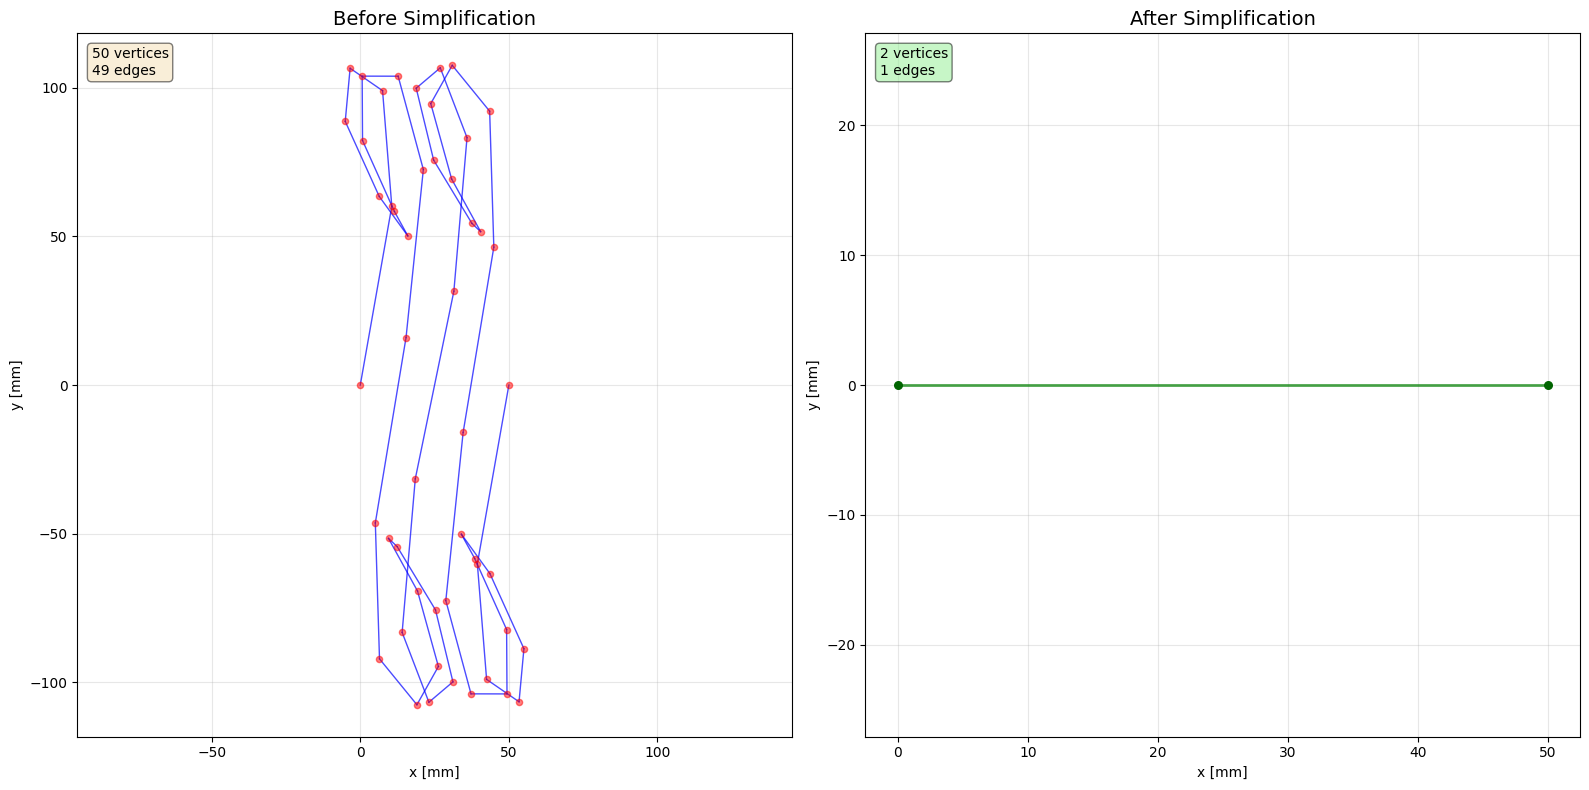

In [11]:
"""
Example: Simplify Evolved Crack Network
========================================

This example shows how to:
1. Import your evolved crack network
2. Simplify it (merge colinear edges, remove small features)
3. Export it back for continued growth
4. Use with CrackNetworkGenerator for further evolution
"""

import numpy as np
import matplotlib.pyplot as plt
from fracture_utils.Ugenerator.crack_network_simplifier import CrackNetworkSimplifier, SimplificationConfig

# Assuming you have your fracture_utils available
# from fracture_utils import CrackNetworkGenerator

# ============================================================================
# STEP 1: Get Your Evolved Network Data
# ============================================================================

# Example: From your crack evolution simulation
# Assuming you have vertices and connectivity from your simulation

# Your evolved network might look like this:
# vertices shape: (n_vertices, 3) = [id, x, y] or (n_vertices, 2) = [x, y]
# connectivity shape: (n_edges, 2) = [v0, v1]

# For this example, let's assume you extract it from your simulation:
"""
# From your simulation code:
evolved_vertices = your_network.get_vertices()  # Get current vertex positions
evolved_connectivity = your_network.get_edges()  # Get current connectivity

# OR if using CrackNetworkV4:
vertices_array = []
for v in net.vertices:
    vertices_array.append([v.id, v.x, v.y])
evolved_vertices = np.array(vertices_array)

connectivity_array = []
for e in net.edges:
    connectivity_array.append([e.v0, e.v1])
evolved_connectivity = np.array(connectivity_array)
"""

# ============================================================================
# EXAMPLE DATA (Replace with your actual network)
# ============================================================================

mm = 1e-3

# Simulated evolved network with many small/colinear segments
np.random.seed(42)

# Create example evolved network (many vertices from growth simulation)
n_vertices = 50
vertices = np.zeros((n_vertices, 3))
vertices[:, 0] = np.arange(n_vertices)  # IDs

# Positions forming a meandering path with many small segments
t = np.linspace(0, 4*np.pi, n_vertices)
vertices[:, 1] = 50*mm * t/np.max(t) + 10*mm*np.sin(5*t)  # x
vertices[:, 2] = 100*mm * (np.sin(t) + 0.5*np.sin(3*t))    # y

# Connectivity: chain of edges
connectivity = np.array([[i, i+1] for i in range(n_vertices-1)])

print("Evolved Network (Before Simplification):")
print(f"  Vertices: {len(vertices)}")
print(f"  Edges: {len(connectivity)}")

# ============================================================================
# STEP 2: Configure Simplification
# ============================================================================

# Option 1: Use defaults
# config = SimplificationConfig()

# Option 2: Custom configuration
config = SimplificationConfig(
    max_angle_deviation=5.0,      # Merge edges if angle deviation < 5°
    min_edge_length=0.5*mm,       # Remove edges shorter than 0.5mm
    merge_at_degree2=True,        # Merge colinear edges at internal nodes
    remove_degree2_nodes=True,    # Remove degree-2 internal nodes
    preserve_tips=True,           # Don't remove crack tips
    preserve_junctions=True,      # Don't modify junctions
    max_merged_edge_length=20*mm  # Don't merge if result > 20mm
)

print("\nSimplification Configuration:")
print(f"  Max angle deviation: {config.max_angle_deviation}°")
print(f"  Min edge length: {config.min_edge_length/mm:.2f} mm")
print(f"  Merge at degree-2: {config.merge_at_degree2}")

# ============================================================================
# STEP 3: Load and Simplify Network
# ============================================================================

# Create simplifier
simplifier = CrackNetworkSimplifier(config=config)

# Load your evolved network
simplifier.load_from_arrays(vertices, connectivity)

# Get statistics before simplification
stats_before = simplifier.get_statistics()
print("\nBefore Simplification:")
print(f"  Vertices: {stats_before['n_vertices']}")
print(f"  Edges: {stats_before['n_edges']}")
print(f"  Tips: {stats_before['n_tips']}")
print(f"  Junctions: {stats_before['n_junctions']}")
print(f"  Internal: {stats_before['n_internal']}")

# Simplify!
simplification_stats = simplifier.simplify(verbose=True)

# Get statistics after simplification
stats_after = simplifier.get_statistics()
print("\nAfter Simplification:")
print(f"  Vertices: {stats_after['n_vertices']}")
print(f"  Edges: {stats_after['n_edges']}")
print(f"  Tips: {stats_after['n_tips']}")
print(f"  Junctions: {stats_after['n_junctions']}")
print(f"  Internal: {stats_after['n_internal']}")

# ============================================================================
# STEP 4: Export Simplified Network
# ============================================================================

# Export to arrays
simplified_vertices, simplified_connectivity = simplifier.to_arrays()

print("\nSimplified Network:")
print(f"  Vertices: {len(simplified_vertices)}")
print(f"  Edges: {len(simplified_connectivity)}")
print(f"  Reduction: {len(vertices) - len(simplified_vertices)} vertices, "
      f"{len(connectivity) - len(simplified_connectivity)} edges")

# ============================================================================
# STEP 5: Use Simplified Network for Continued Growth
# ============================================================================

# Option A: Convert back to your simulation format
"""
# Load into your CrackNetworkV4 or other format
simplified_net = CrackNetworkV4.from_vertices_connectivity(
    vertices=simplified_vertices,
    connectivity=simplified_connectivity,
    Nv_max=len(simplified_vertices),
    validate=True
)

# Continue growth simulation
# ... your growth code ...
"""

# Option B: Use with CrackNetworkGenerator for further evolution
"""
from fracture_utils import CrackNetworkGenerator

# Create generator
gen = CrackNetworkGenerator(domain_size=(100*mm, 200*mm))

# Load simplified network
gen.load_from_arrays(simplified_vertices, simplified_connectivity)

# Add more cracks to the simplified network
gen.generate_network(
    n_crack_paths=5,  # Add 5 more crack paths
    segments_per_path_mean=3,
    edge_length_mean=5*mm,
    allow_intersections=True
)

# Export combined network
final_vertices, final_connectivity = gen.to_arrays(return_types=False)
"""

# ============================================================================
# STEP 6: Visualize Before/After
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot original evolved network
ax1.set_title("Before Simplification", fontsize=14, fontweight='bold')
for v0, v1 in connectivity:
    pos0 = vertices[int(v0), 1:]
    pos1 = vertices[int(v1), 1:]
    ax1.plot([pos0[0]/mm, pos1[0]/mm], 
             [pos0[1]/mm, pos1[1]/mm], 
             'b-', linewidth=1, alpha=0.7)

ax1.scatter(vertices[:, 1]/mm, vertices[:, 2]/mm, 
           c='red', s=20, zorder=5, alpha=0.5)
ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')
ax1.text(0.02, 0.98, f'{len(vertices)} vertices\n{len(connectivity)} edges',
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot simplified network
ax2.set_title("After Simplification", fontsize=14, fontweight='bold')
for v0, v1 in simplified_connectivity:
    pos0 = simplified_vertices[int(v0), 1:]
    pos1 = simplified_vertices[int(v1), 1:]
    ax2.plot([pos0[0]/mm, pos1[0]/mm], 
             [pos0[1]/mm, pos1[1]/mm], 
             'g-', linewidth=2, alpha=0.7)

ax2.scatter(simplified_vertices[:, 1]/mm, simplified_vertices[:, 2]/mm, 
           c='darkgreen', s=30, zorder=5)
ax2.set_xlabel('x [mm]')
ax2.set_ylabel('y [mm]')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')
ax2.text(0.02, 0.98, 
         f'{len(simplified_vertices)} vertices\n{len(simplified_connectivity)} edges',
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('network_simplification_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved comparison plot: network_simplification_comparison.png")

# ============================================================================
# STEP 7: Advanced - Iterative Simplification
# ============================================================================

def iterative_simplification(vertices, connectivity, 
                             max_iterations=5,
                             config=None):
    """
    Apply simplification iteratively until no more changes occur.
    
    Sometimes merging edges creates new opportunities for simplification.
    """
    if config is None:
        config = SimplificationConfig()
    
    print("\n" + "="*60)
    print("ITERATIVE SIMPLIFICATION")
    print("="*60)
    
    current_vertices = vertices.copy()
    current_connectivity = connectivity.copy()
    
    for iteration in range(max_iterations):
        print(f"\nIteration {iteration + 1}:")
        print(f"  Input: {len(current_vertices)} vertices, "
              f"{len(current_connectivity)} edges")
        
        # Simplify
        simplifier = CrackNetworkSimplifier(config=config)
        simplifier.load_from_arrays(current_vertices, current_connectivity)
        stats = simplifier.simplify(verbose=False)
        
        # Export
        new_vertices, new_connectivity = simplifier.to_arrays()
        
        # Check if converged
        if (len(new_vertices) == len(current_vertices) and 
            len(new_connectivity) == len(current_connectivity)):
            print("  ✓ Converged (no more changes)")
            break
        
        current_vertices = new_vertices
        current_connectivity = new_connectivity
        
        print(f"  Output: {len(new_vertices)} vertices, "
              f"{len(new_connectivity)} edges")
    
    return current_vertices, current_connectivity

# Example usage
final_vertices, final_connectivity = iterative_simplification(
    vertices, connectivity, 
    max_iterations=5,
    config=config
)

print("\n" + "="*60)
print("FINAL RESULT")
print("="*60)
print(f"Original: {len(vertices)} vertices, {len(connectivity)} edges")
print(f"Final: {len(final_vertices)} vertices, {len(final_connectivity)} edges")
print(f"Total reduction: {len(vertices) - len(final_vertices)} vertices, "
      f"{len(connectivity) - len(final_connectivity)} edges")


In [ ]:
"""
QUICK GUIDE: Simplify Your Evolved Crack Network
=================================================

Step-by-step guide to simplify your evolved network from the image.
"""

import numpy as np
from crack_network_simplifier import CrackNetworkSimplifier, SimplificationConfig

# ============================================================================
# YOUR CURRENT WORKFLOW (from your image)
# ============================================================================

"""
You have an evolved crack network that looks complex with many segments.
From your plot, it appears you have:
- Many vertices (v1, v2, v38, v41, v42, v44, v47, v48, etc.)
- Many edges connecting them
- Some very small segments
- Some nearly-colinear segments
"""

# ============================================================================
# STEP 1: Extract Network from Your Simulation
# ============================================================================

# Method A: If using CrackNetworkV4 from Usolver
"""
from fracture_utils.Usolver.network import CrackNetworkV4

# Assuming 'net' is your current network
vertices_list = []
for v in net.vertices:
    vertices_list.append([v.id, v.x, v.y])
vertices = np.array(vertices_list)

connectivity_list = []
for e in net.edges:
    connectivity_list.append([e.v0, e.v1])
connectivity = np.array(connectivity_list)
"""

# Method B: If you have arrays already
"""
# Directly from your simulation
vertices = your_network.vertices  # Shape (n, 3) or (n, 2)
connectivity = your_network.edges  # Shape (m, 2)
"""

# ============================================================================
# STEP 2: Configure What to Simplify
# ============================================================================

mm = 1e-3

# Create configuration
config = SimplificationConfig(
    # Merge edges if angle deviation < 5 degrees
    max_angle_deviation=5.0,
    
    # Remove edges shorter than 0.5mm (adjust based on your scale)
    min_edge_length=0.5*mm,
    
    # Merge colinear segments at degree-2 nodes
    merge_at_degree2=True,
    
    # Remove degree-2 internal nodes (simplify polylines)
    remove_degree2_nodes=True,
    
    # Keep crack tips
    preserve_tips=True,
    
    # Keep junctions
    preserve_junctions=True,
    
    # Don't merge if result would be > 20mm
    max_merged_edge_length=20*mm
)

# Adjust these based on your needs:
# - If you want MORE simplification: increase max_angle_deviation (e.g., 10°)
# - If you want to remove more small features: increase min_edge_length
# - If you want to preserve more detail: decrease max_angle_deviation

# ============================================================================
# STEP 3: Simplify
# ============================================================================

# Create simplifier
simplifier = CrackNetworkSimplifier(config=config)

# Load your network
simplifier.load_from_arrays(vertices, connectivity)

# Get stats before
print("Before simplification:")
stats = simplifier.get_statistics()
print(f"  Vertices: {stats['n_vertices']}")
print(f"  Edges: {stats['n_edges']}")

# Simplify!
simplifier.simplify(verbose=True)

# Get stats after
print("\nAfter simplification:")
stats = simplifier.get_statistics()
print(f"  Vertices: {stats['n_vertices']}")
print(f"  Edges: {stats['n_edges']}")

# ============================================================================
# STEP 4: Export Simplified Network
# ============================================================================

# Get simplified arrays
simplified_vertices, simplified_connectivity = simplifier.to_arrays()

print(f"\n✓ Simplified network ready:")
print(f"  vertices shape: {simplified_vertices.shape}")
print(f"  connectivity shape: {simplified_connectivity.shape}")

# ============================================================================
# STEP 5: Convert Back to Your Format and Continue Growth
# ============================================================================

# Option 1: Load back into CrackNetworkV4
"""
from fracture_utils.Usolver.network import CrackNetworkV4

simplified_net = CrackNetworkV4.from_vertices_connectivity(
    vertices=simplified_vertices,
    connectivity=simplified_connectivity,
    Nv_max=len(simplified_vertices),
    validate=True
)

# Now continue your crack evolution with simplified_net
# ... your growth algorithm ...
"""

# Option 2: Use with CrackNetworkGenerator to add more cracks
"""
from fracture_utils import CrackNetworkGenerator

gen = CrackNetworkGenerator(domain_size=(200*mm, 300*mm))
gen.load_from_arrays(simplified_vertices, simplified_connectivity)

# Add more crack paths to the simplified network
gen.generate_network(
    n_crack_paths=3,
    segments_per_path_mean=5,
    edge_length_mean=10*mm,
    allow_intersections=True
)

# Get final network
final_vertices, final_connectivity = gen.to_arrays(return_types=False)
"""

# ============================================================================
# STEP 6: Visual Comparison (Optional)
# ============================================================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Before
ax1.set_title("Your Evolved Network (Before)")
for v0, v1 in connectivity:
    p0 = vertices[int(v0), 1:]
    p1 = vertices[int(v1), 1:]
    ax1.plot([p0[0]/mm, p1[0]/mm], [p0[1]/mm, p1[1]/mm], 'b-', lw=1)
ax1.scatter(vertices[:, 1]/mm, vertices[:, 2]/mm, c='red', s=10)
ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# After
ax2.set_title("Simplified Network (After)")
for v0, v1 in simplified_connectivity:
    p0 = simplified_vertices[int(v0), 1:]
    p1 = simplified_vertices[int(v1), 1:]
    ax2.plot([p0[0]/mm, p1[0]/mm], [p0[1]/mm, p1[1]/mm], 'g-', lw=2)
ax2.scatter(simplified_vertices[:, 1]/mm, simplified_vertices[:, 2]/mm, 
           c='darkgreen', s=20)
ax2.set_xlabel('x [mm]')
ax2.set_ylabel('y [mm]')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

plt.tight_layout()
plt.savefig('my_network_simplified.png', dpi=150)
print("\n✓ Saved: my_network_simplified.png")

# ============================================================================
# KEY PARAMETERS TO ADJUST
# ============================================================================

print("\n" + "="*60)
print("TUNING GUIDE")
print("="*60)
print("""
Adjust these parameters based on your needs:

1. max_angle_deviation (default: 5.0 degrees)
   - INCREASE (e.g., 10°) for MORE aggressive merging
   - DECREASE (e.g., 2°) to preserve more shape details
   
2. min_edge_length (default: 0.5mm)
   - INCREASE to remove more small features
   - DECREASE to preserve finer details
   
3. merge_at_degree2 (default: True)
   - True: Merge colinear edges at internal nodes
   - False: Keep all edges separate
   
4. remove_degree2_nodes (default: True)
   - True: Simplify polylines (remove internal nodes)
   - False: Keep all vertices

Example for AGGRESSIVE simplification:
    config = SimplificationConfig(
        max_angle_deviation=15.0,
        min_edge_length=2.0*mm,
        merge_at_degree2=True,
        remove_degree2_nodes=True
    )

Example for CONSERVATIVE simplification:
    config = SimplificationConfig(
        max_angle_deviation=2.0,
        min_edge_length=0.1*mm,
        merge_at_degree2=False,
        remove_degree2_nodes=False
    )
""")
